# GANisme — 01. Analyse exploratoire du catalogue d'œuvres

**Objectif du notebook** : décrire le plus finement possible le catalogue brut `data/art_catalog.xlsx`
avant de scraper les images et d'entraîner un GAN générateur de peintures.

Le catalogue est un export de la **Web Gallery of Art** (WGA, `www.wga.hu`), un musée virtuel
consacré à l'art européen du XIᵉ au XIXᵉ siècle. Chaque ligne décrit une œuvre et pointe vers sa page HTML.

Au-delà de la description, cette EDA doit répondre à des questions **utiles pour la suite du projet** :

1. Quelle est la **qualité** des données (manquants, doublons, formats hétérogènes, erreurs de saisie) ?
2. Combien de **peintures** peut-on réellement exploiter, et que contiennent-elles (sujets, écoles, époques, techniques) ?
3. Quels **biais** le GAN risque-t-il d'apprendre (sur-représentation d'un style, d'une époque, d'un sujet) ?
4. Quelles **contraintes de preprocessing** anticiper (format des tableaux, quasi-doublons, fresques photographiées in situ) ?

**Plan**

| § | Contenu |
|---|---|
| 1 | Chargement et premier aperçu |
| 2 | Qualité des données brutes |
| 3 | Vue d'ensemble : toutes les formes d'art |
| 4 | Feature engineering : extraction de l'information cachée dans le texte |
| 5 | Focus sur les peintures (cible du GAN) |
| 6 | Analyse multivariée et tests statistiques |
| 7 | Synthèse et implications pour le GAN |
| 8 | Export du catalogue des peintures enrichi |

In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from wordcloud import WordCloud

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "art_catalog.xlsx"
DATA_OUT = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# --- Charte graphique -------------------------------------------------------
# Palette catégorielle validée daltonisme (ordre fixe, jamais recyclé) ;
# une seule teinte (bleu) pour les magnitudes ; bleu <-> rouge + gris neutre pour le divergent.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER = "#c3c2b7"      # catégorie « Autres »
MAIN = CAT[0]
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#f4f8fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#b52d2d"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    # Sauvegarde chaque figure pour la présentation finale.
    fig.savefig(FIG_DIR / f"{name}.png")


def barh(s, title, xlabel="Nombre d'œuvres", ax=None, color=MAIN, pct_of=None, label=True):
    # Barres horizontales triées (la plus grande en haut), valeurs en bout de barre.
    s = s.sort_values()
    if ax is None:
        _, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(s) + 1)))
    ax.barh(s.index.astype(str), s.values, color=color, height=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
    if label:
        total = pct_of if pct_of is not None else s.sum()
        for i, v in enumerate(s.values):
            txt = f" {v:,.0f}".replace(",", " ") + (f"  ({v / total:.1%})" if total else "")
            ax.text(v, i, txt, va="center", fontsize=8.5, color=INK2)
        ax.set_xlim(0, s.max() * 1.22)
    return ax


def top_n(s, n, other="Autres"):
    # Garde les n modalités les plus fréquentes, regroupe le reste dans « Autres ».
    keep = s.value_counts().index[:n]
    return s.where(s.isin(keep), other)


def roman(n):
    vals = [(10, "X"), (9, "IX"), (5, "V"), (4, "IV"), (1, "I")]
    out = ""
    for v, r in vals:
        while n >= v:
            out += r
            n -= v
    return out

## 1. Chargement et premier aperçu

In [4]:
xls = pd.ExcelFile(DATA_RAW)
print("Feuilles :", xls.sheet_names)
raw = pd.read_excel(xls, sheet_name=0)
df = raw.copy()
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes".replace(",", " "))
print(f"Mémoire    : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
df.head()

Feuilles : ['catalog']
Dimensions : 52 867 lignes × 11 colonnes
Mémoire    : 40.2 Mo


,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
0,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Venus and Adonis,1574-88,"Oil on canvas, 68 x 95 cm","Fogg Art Museum, Harvard University, Cambridge",https://www.wga.hu/html/a/aachen/adonis.html,painting,mythological,German,1601-1650
1,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",https://www.wga.hu/html/a/aachen/allegory.html,painting,mythological,German,1601-1650
2,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)","Allegory of Peace, Art and Abundance",1602,"Oil on canvas, 197 x 142 cm","The Hermitage, St. Petersburg",https://www.wga.hu/html/a/aachen/allegorz.html,painting,mythological,German,1601-1650
3,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)","Jupiter, Antiope and Cupid",1595-98,"Oil on copper, 31 x 21 cm","Kunsthistorisches Museum, Vienna",https://www.wga.hu/html/a/aachen/antiope.html,painting,mythological,German,1601-1650
4,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)","Pallas Athena, Venus and Juno",1593,"Oil on canvas, 54 x 67 cm","Museum of Fine Arts, Boston",https://www.wga.hu/html/a/aachen/athena.html,painting,mythological,German,1601-1650


In [5]:
df.sample(8, random_state=42)

,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
28405,"MANSART, François","(b. 1598, Paris, d. 1666, Paris)",Interior view,begun 1645,Photo,"Val-de-Grâce, Paris",https://www.wga.hu/html/m/mansart/2/grace5.html,architecture,other,French,1601-1650
50484,"VERONESE, Paolo","(b. 1528, Verona, d. 1588, Venezia)",Martyrdom of St Sebastian (detail),1565,Oil on canvas,"San Sebastiano, Venice",https://www.wga.hu/html/v/veronese/02a/1choir/3martyr3.html,painting,religious,Italian,1551-1600
29587,MASTER of the Codex of Saint George,(active first half of the 14th century),Diptych,c. 1315,"Tempera and gold on panel, 28 x 15 cm (each wing)",Private collection,https://www.wga.hu/html/m/master/codex/zdiptych.html,painting,religious,Italian,1301-1350
34126,"MOSAIC ARTIST, Italian",(active 1180s in Monreale),"Sanctuary, main apse (detail)",1180s,Mosaic,"Cathedral, Monreale",https://www.wga.hu/html/zgothic/mosaics/5monreal/1sanctu3.html,mosaic,religious,Italian,1151-1200
40481,"RENOIR, Pierre-Auguste","(b, 1841, Limoges, d. 1919, Cagnes-sur-Mer)",Seated Bather,1914,"Oil on canvas, 81 x 67 cm","Art Institute, Chicago",https://www.wga.hu/html/r/renoir/4/4renoi18.html,painting,portrait,French,1851-1900
49879,"VELÁZQUEZ, Diego Rodriguez de Silva y","(b. 1599, Sevilla, d. 1660, Madrid)","Infanta Doña María, Queen of Hungary",1630,"Oil on canvas, 60 x 46 cm","Museo del Prado, Madrid",https://www.wga.hu/html/v/velazque/02/0215vela.html,painting,portrait,Spanish,1601-1650
34037,"MOSAIC ARTIST, Italian",(active 520s in Rome),Apse decoration,526-30,Mosaic,"Basilica di Santi Cosma e Damiano, Rome",https://www.wga.hu/html/zearly/1/4mosaics/1rome/4cosma/cosma1.html,mosaic,religious,Italian,0501-0550
23367,"HOLBEIN, Hans the Younger","(b. 1497, Augsburg, d. 1543, London)",Signboard for a Schoolmaster,1516,"Pine panel, 56 x 66 cm","Öffentliche Kunstsammlung, Basel",https://www.wga.hu/html/h/holbein/hans_y/1518/1signboa.html,painting,other,German,1501-1550


In [6]:
# Dictionnaire des variables : type, cardinalité, exemples
def profile(frame):
    rows = []
    for c in frame.columns:
        s = frame[c]
        types = s.map(lambda v: type(v).__name__).value_counts()
        rows.append({
            "colonne": c,
            "types Python": ", ".join(f"{t} ({n})" for t, n in types.items()),
            "valeurs uniques": s.nunique(),
            "% unique": round(100 * s.nunique() / len(s), 2),
            "modalité la plus fréquente": s.astype(str).value_counts().index[0],
            "fréquence": s.astype(str).value_counts().iloc[0],
            "exemple": s.iloc[len(s) // 2],
        })
    return pd.DataFrame(rows).set_index("colonne")

profile(df)

,types Python,valeurs uniques,% unique,modalité la plus fréquente,fréquence,exemple
colonne,,,,,,
AUTHOR,str (52867),5767,10.91,MICHELANGELO Buonarroti,638,"LICINIO, Bernardino"
BORN-DIED,str (52867),8189,15.49,"(b. 1475, Caprese, d. 1564, Roma)",638,"(b. ca. 1489, Poscante, d. ca. 1565, Venezia)"
TITLE,str (52867),31236,59.08,Exterior view,1894,Portrait of a Woman
DATE,"str (37393), int (15474)",5783,10.94,-,4800,1522
TECHNIQUE,str (52867),23530,44.51,Photo,5072,"Oil on wood, 83,5 x 71,5 cm"
LOCATION,str (52867),5550,10.50,Private collection,6114,"Szépmûvészeti Múzeum, Budapest"
URL,str (52867),52867,100.00,https://www.wga.hu/html/a/aachen/adonis.html,1,https://www.wga.hu/html/l/licinio/portrai1.html
FORM,str (52867),13,0.02,painting,32438,painting
TYPE,str (52867),10,0.02,religious,21377,portrait


**Lecture du dictionnaire**

| Variable | Rôle | Nature |
|---|---|---|
| `AUTHOR` | Artiste (format `NOM, Prénom`) | Catégorielle, très haute cardinalité |
| `BORN-DIED` | Dates et lieux de naissance / mort — **texte libre** | À parser |
| `TITLE` | Titre de l'œuvre (en anglais) | Texte libre |
| `DATE` | Date de réalisation — **types mixtes** (entier ou texte : `c. 1500`, `1490s`, `1574-88`…) | À parser |
| `TECHNIQUE` | Technique + support + **dimensions** (`Oil on canvas, 68 x 95 cm`) | À parser |
| `LOCATION` | Musée et ville de conservation | Catégorielle |
| `URL` | Page HTML de l'œuvre sur la WGA — **identifiant unique** | Clé |
| `FORM` | Forme d'art (peinture, sculpture, architecture…) | Catégorielle, 13 modalités |
| `TYPE` | Genre / sujet (religieux, portrait, paysage…) | Catégorielle, 10 modalités |
| `SCHOOL` | École nationale | Catégorielle, 26 modalités |
| `TIMEFRAME` | Tranche de 50 ans | Ordinale, 34 modalités |

Trois colonnes (`BORN-DIED`, `DATE`, `TECHNIQUE`) concentrent une information structurée enfouie dans du texte libre :
c'est là que l'EDA doit creuser (§4).

## 2. Qualité des données brutes

### 2.1 Valeurs manquantes explicites et implicites

Aucune cellule n'est vide au sens de pandas, mais le catalogue encode l'absence d'information par des
**valeurs sentinelles** (`-`, `Private collection`, `UNKNOWN MASTER`…). Il faut les compter pour avoir la vraie
complétude.

In [7]:
sentinels = {
    "NaN (pandas)": lambda s: s.isna(),
    "'-'": lambda s: s.astype(str).str.strip().eq("-"),
    "chaîne vide": lambda s: s.astype(str).str.strip().eq(""),
    "espaces parasites": lambda s: s.astype(str).ne(s.astype(str).str.strip()),
}
miss = pd.DataFrame({name: {c: int(f(df[c]).sum()) for c in df.columns} for name, f in sentinels.items()})
miss["% '-'"] = (100 * miss["'-'"] / len(df)).round(2)
miss

,NaN (pandas),'-',chaîne vide,espaces parasites,% '-'
AUTHOR,0,0,0,0,0.00
BORN-DIED,0,0,0,0,0.00
TITLE,0,0,0,0,0.00
DATE,0,4800,0,0,9.08
TECHNIQUE,0,1,0,0,0.00
LOCATION,0,61,0,0,0.12
URL,0,0,0,0,0.00
FORM,0,0,0,0,0.00
TYPE,0,0,0,0,0.00
SCHOOL,0,0,0,0,0.00


In [8]:
implicit = {
    "DATE = '-' (date inconnue)": df["DATE"].astype(str).eq("-").sum(),
    "LOCATION = '-' (localisation inconnue)": df["LOCATION"].eq("-").sum(),
    "LOCATION = 'Private collection'": df["LOCATION"].eq("Private collection").sum(),
    "AUTHOR = 'UNKNOWN MASTER, …' (anonyme)": df["AUTHOR"].str.startswith("UNKNOWN MASTER").sum(),
    "TECHNIQUE sans dimensions": (~df["TECHNIQUE"].str.contains(r"\d\s*x\s*\d")).sum(),
    "SCHOOL = 'Other'": df["SCHOOL"].eq("Other").sum(),
    "TYPE = 'other'": df["TYPE"].eq("other").sum(),
    "FORM = 'others'": df["FORM"].eq("others").sum(),
}
implicit = pd.Series(implicit, name="nb").to_frame()
implicit["%"] = (100 * implicit["nb"] / len(df)).round(1)
implicit

,nb,%
DATE = '-' (date inconnue),4800,9.1
LOCATION = '-' (localisation inconnue),61,0.1
LOCATION = 'Private collection',6114,11.6
"AUTHOR = 'UNKNOWN MASTER, …' (anonyme)",1019,1.9
TECHNIQUE sans dimensions,24841,47.0
SCHOOL = 'Other',259,0.5
TYPE = 'other',7167,13.6
FORM = 'others',11,0.0


### 2.2 Doublons

L'`URL` est unique ligne à ligne. Mais une même œuvre peut apparaître plusieurs fois sous des URL différentes :
typiquement les **détails** d'un tableau (`Title (detail)`) ou plusieurs vues d'une même fresque.
Pour un GAN, ces lignes produiront des **images quasi identiques** — un risque de mémorisation.

In [9]:
dup = {
    "lignes strictement identiques": df.duplicated().sum(),
    "URL dupliquées": df["URL"].duplicated().sum(),
    "identiques hors URL": df.drop(columns="URL").duplicated().sum(),
    "même (AUTHOR, TITLE)": df.duplicated(["AUTHOR", "TITLE"]).sum(),
    "titre contenant « detail »": df["TITLE"].str.contains(r"\bdetail", case=False).sum(),
}
pd.Series(dup, name="nb").to_frame().assign(**{"%": lambda d: (100 * d["nb"] / len(df)).round(1)})

,nb,%
lignes strictement identiques,0,0.0
URL dupliquées,0,0.0
identiques hors URL,6626,12.5
"même (AUTHOR, TITLE)",11131,21.1
titre contenant « detail »,6826,12.9


In [10]:
# Exemple : un groupe de lignes identiques hors URL
key = df.drop(columns="URL").duplicated(keep=False)
grp = df[key].groupby(list(df.columns.drop("URL"))).size().sort_values(ascending=False)
print("Plus gros groupe de doublons (hors URL) :", grp.iloc[0], "lignes")
ex = grp.index[0]
df[(df["AUTHOR"] == ex[0]) & (df["TITLE"] == ex[2])][["AUTHOR", "TITLE", "DATE", "FORM", "URL"]].head(6)

Plus gros groupe de doublons (hors URL) : 35 lignes


,AUTHOR,TITLE,DATE,FORM,URL
19300,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/01_lastj.html
19301,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/03_lastj.html
19302,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/04_lastj.html
19303,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/05_lastj.html
19304,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/05_lastk.html
19305,GIOTTO di Bondone,Last Judgment (detail),1306,painting,https://www.wga.hu/html/g/giotto/padova/4lastjud/06_lastj.html


### 2.3 Types mixtes et erreurs de saisie

In [11]:
print("Types dans DATE :")
print(df["DATE"].map(lambda v: type(v).__name__).value_counts().to_string(), "\n")

# BORN-DIED : format attendu « (b. AAAA, Lieu, d. AAAA, Lieu) »
bd_typo = df[df["BORN-DIED"].str.contains(r"^\(b,")]
print(f"BORN-DIED avec la faute de frappe '(b,' au lieu de '(b.' : {len(bd_typo)} lignes "
      f"— artiste(s) : {bd_typo['AUTHOR'].unique().tolist()}")

# Contrôle de l'encodage : les accents sont-ils bien lus ?
has_accent = df["LOCATION"].str.contains(r"[éèàüöäç]").sum()
has_mojibake = df.apply(lambda s: s.astype(str).str.contains("\ufffd|Ã©|Ã¨")).sum().sum()
print(f"LOCATION avec accents correctement décodés : {has_accent} ; cellules mal encodées : {has_mojibake}")

# Format des URL
url_ok = df["URL"].str.match(r"^https://www\.wga\.hu/html/.+\.html$")
print(f"URL au format https://www.wga.hu/html/…/….html : {url_ok.mean():.2%}")

Types dans DATE :
DATE
str    37393
int    15474 

BORN-DIED avec la faute de frappe '(b,' au lieu de '(b.' : 111 lignes — artiste(s) : ['RENOIR, Pierre-Auguste']
LOCATION avec accents correctement décodés : 7358 ; cellules mal encodées : 0
URL au format https://www.wga.hu/html/…/….html : 100.00%


In [12]:
# Cohérence FORM / TECHNIQUE : des « peintures » dont la technique n'est pas picturale ?
paint = df[df["FORM"] == "painting"]
non_pict = paint["TECHNIQUE"].str.split(", ").str[0].str.lower()
suspects = non_pict[non_pict.str.contains(r"^(ivory|marble|bronze|stone|photo|silver|gold$|enamel|glass|stucco|terracotta)")]
print(f"{len(suspects)} peintures avec une technique non picturale :")
suspects.value_counts().head(12)

154 peintures avec une technique non picturale :


TECHNIQUE
photo                65
marble               30
bronze               21
ivory                 5
enamel on copper      5
terracotta            5
marble and fresco     5
stone                 4
stucco and fresco     3
glass                 2
stucco                2
silver                1
Name: count, dtype: int64

**Bilan qualité**

- **Pas de manquants au sens strict**, mais 4 800 dates `-` (≈ 9 %), 12 % de collections privées et près de la moitié
  des techniques sans dimensions : la complétude réelle est bien inférieure à ce que laisse croire `isna()`.
- **Aucun doublon d'URL** : l'URL est une clé primaire fiable pour le scraping.
- **Plusieurs milliers de quasi-doublons** : lignes identiques hors URL et titres « (detail) ». Ce sont des recadrages
  d'un même tableau — à traiter avant l'entraînement.
- **`DATE` a des types mixtes** (entiers et chaînes) : il faut la normaliser avant toute analyse temporelle.
- **Erreurs de saisie ponctuelles** (`(b,` au lieu de `(b.` sur les 111 œuvres de Renoir) et 154 « peintures » dont la
  technique n'est pas picturale (`Photo` pour des vues in situ, marbre, bronze…) : la variable `FORM` n'est pas parfaite.
- **Encodage correct** : les accents (Musée, Szépművészeti…) sont bien décodés.

## 3. Vue d'ensemble : toutes les formes d'art

Le sujet demande de **ne garder que les peintures**. Avant de filtrer, regardons ce que l'on écarte.

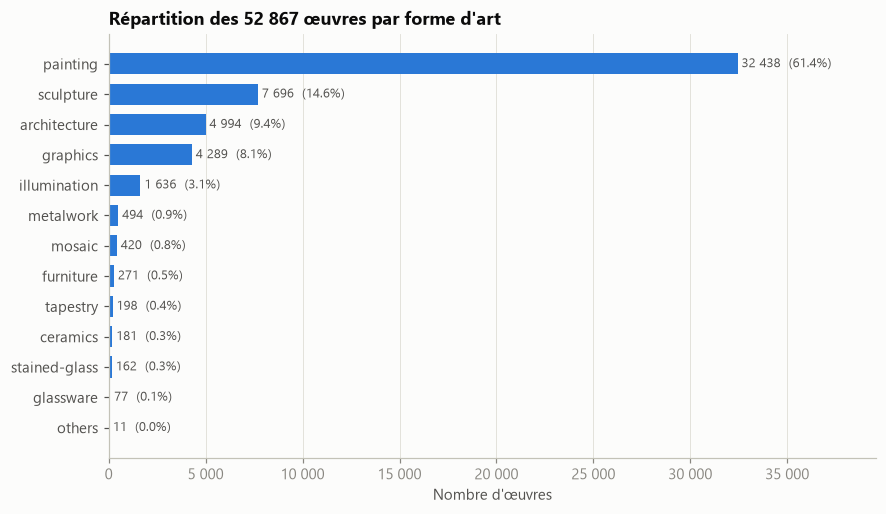

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
barh(df["FORM"].value_counts(), "Répartition des 52 867 œuvres par forme d'art", ax=ax)
save(fig, "01_form_distribution")
plt.show()

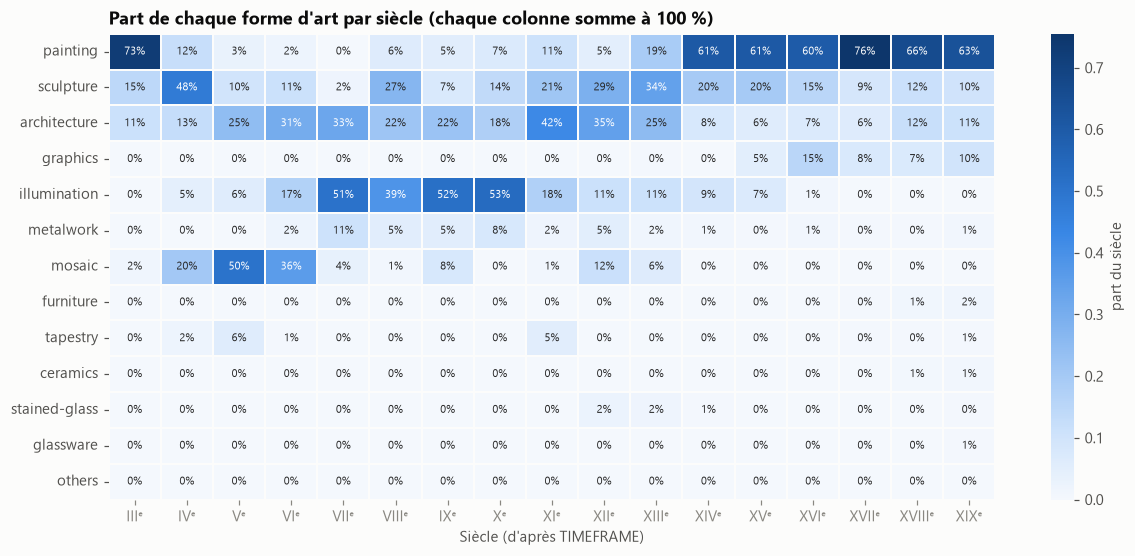

In [14]:
# Forme × siècle : les peintures dominent-elles à toutes les époques ?
df["TF_START"] = df["TIMEFRAME"].str.split("-").str[0].astype(int)
df["CENTURY"] = df["TF_START"] // 100 + 1
ct = pd.crosstab(df["FORM"], df["CENTURY"], normalize="columns")
ct = ct.loc[df["FORM"].value_counts().index]
ct.columns = [f"{roman(c)}ᵉ" for c in ct.columns]

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(ct, cmap=SEQ, annot=True, fmt=".0%", annot_kws={"size": 7.5}, cbar_kws={"label": "part du siècle"},
            linewidths=1, linecolor=SURFACE, ax=ax)
ax.set_title("Part de chaque forme d'art par siècle (chaque colonne somme à 100 %)")
ax.set_xlabel("Siècle (d'après TIMEFRAME)"); ax.set_ylabel("")
save(fig, "02_form_by_century")
plt.show()

**Observations**

- Les **peintures représentent ~61 %** du catalogue (32 438 œuvres) : c'est de loin la forme majoritaire,
  suivie de la sculpture et de l'architecture.
- Avant le XIIIᵉ siècle, le catalogue est dominé par l'**architecture**, les **mosaïques** et les **enluminures** :
  la peinture de chevalet n'existe pas encore. Filtrer sur `painting` revient donc aussi, mécaniquement,
  à **restreindre la période** étudiée.
- Les formes `graphics` (dessins, gravures) et `illumination` (manuscrits) sont visuellement proches de la peinture ;
  elles pourraient servir d'**augmentation de données** mais changeraient le style appris. On s'en tient ici aux peintures.

## 4. Feature engineering : extraire l'information cachée dans le texte

Quatre colonnes texte contiennent des données structurées. On les transforme en variables exploitables :

| Source | Variables créées |
|---|---|
| `DATE` | `YEAR_START`, `YEAR_END`, `YEAR` (milieu), `DATE_PRECISION` |
| `TIMEFRAME` | `TF_START`, `CENTURY` |
| `BORN-DIED` | `BIRTH_YEAR`, `DEATH_YEAR`, `BIRTH_PLACE`, `DEATH_PLACE`, `LIFESPAN`, `BIO_STATUS` |
| `TECHNIQUE` | `MEDIUM`, `MEDIUM_FAMILY`, `SUPPORT`, `HEIGHT_CM`, `WIDTH_CM`, `ASPECT`, `ORIENTATION` |
| `TITLE` | `IS_DETAIL`, `TITLE_BASE` |
| `LOCATION` | `CITY`, `IS_PRIVATE` |
| `URL` | `IMAGE_URL` (URL présumée de l'image, à vérifier au scraping) |

### 4.1 Normalisation de `DATE`

In [15]:
RE_CENTURY = re.compile(r"(\d{1,2})(?:st|nd|rd|th)\s+century", re.I)
RE_DECADE = re.compile(r"\b(\d{3,4})s\b")
RE_RANGE = re.compile(r"\b(\d{3,4})\s*[-–/]\s*(\d{1,4})\b")
RE_YEAR = re.compile(r"\b(\d{3,4})\b")
RE_CIRCA = re.compile(r"^\s*(c\.|ca\.|about|around|circa)", re.I)
RE_APPROX = re.compile(r"\b(after|before|c\.|ca\.)", re.I)


def complete_end(start, end):
    # '1574-88' -> 1588 ; '1595-1605' -> 1605 ; '1304-06' -> 1306
    s = str(start)
    return int(end) if len(end) >= len(s) else int(s[: len(s) - len(end)] + end)


def parse_date(v):
    if isinstance(v, (int, np.integer)):
        if v <= 2025:
            return v, v, "exacte"
        s = str(v)
        if len(s) == 6:                  # 162628 -> intervalle 1626-28 (tiret perdu à la saisie)
            return int(s[:4]), complete_end(int(s[:4]), s[4:]), "intervalle"
        return np.nan, np.nan, "erreur de saisie"
    s = str(v).strip()
    if s in ("-", "", "nan"):
        return np.nan, np.nan, "inconnue"
    if (m := RE_CENTURY.search(s)):
        c = int(m.group(1))
        return (c - 1) * 100 + 1, c * 100, "siècle"
    if (m := RE_DECADE.search(s)):
        y = int(m.group(1))
        return y, y + 9, "décennie"
    if (m := RE_RANGE.search(s)):
        a, b = int(m.group(1)), complete_end(int(m.group(1)), m.group(2))
        if b < a or b - a > 150:        # garde-fou contre les faux intervalles
            b = a
        return a, b, "intervalle"
    if (m := RE_YEAR.search(s)):
        y = int(m.group(1))
        prec = "circa" if RE_CIRCA.search(s) else ("approximative" if RE_APPROX.search(s) else "exacte")
        return y, y, prec
    return np.nan, np.nan, "inconnue"


bad_int = df.loc[df["DATE"].map(lambda v: isinstance(v, (int, np.integer)) and v > 2025), ["AUTHOR", "DATE", "TIMEFRAME"]]
print("Dates entières aberrantes dans le brut (> 2025) :")
print(bad_int.to_string(), "\n")
parsed = df["DATE"].map(parse_date)
df["YEAR_START"] = parsed.str[0].astype(float)
df["YEAR_END"] = parsed.str[1].astype(float)
df["DATE_PRECISION"] = parsed.str[2]
df["YEAR"] = (df["YEAR_START"] + df["YEAR_END"]) / 2
df["DATE_SPAN"] = df["YEAR_END"] - df["YEAR_START"]

print(f"Dates converties en année : {df['YEAR'].notna().mean():.1%} "
      f"(= 100 % des dates renseignées : {df['YEAR'].notna().sum() / (df['DATE'].astype(str) != '-').sum():.1%})")
df["DATE_PRECISION"].value_counts().to_frame("nb").assign(**{"%": lambda d: (100 * d["nb"] / len(df)).round(1)})

Dates entières aberrantes dans le brut (> 2025) :
                            AUTHOR    DATE  TIMEFRAME
11952  COUWENBERGH, Christiaen van  162628  1601-1650
13760                DEVIS, Arthur   11757  1701-1750
33344              MOMPER, Joos de  162123  1601-1650 

Dates converties en année : 90.9% (= 100 % des dates renseignées : 100.0%)


,nb,%
DATE_PRECISION,,
intervalle,17046,32.2
exacte,16509,31.2
circa,10179,19.3
inconnue,4811,9.1
décennie,3215,6.1
siècle,623,1.2
approximative,483,0.9
erreur de saisie,1,0.0


In [16]:
# Contrôle visuel du parsing sur un échantillon de formats variés
check = (df.sample(frac=1, random_state=0).groupby("DATE_PRECISION").head(3)
         .sort_values("DATE_PRECISION")[["DATE", "YEAR_START", "YEAR_END", "YEAR", "DATE_PRECISION"]])
check

,DATE,YEAR_START,YEAR_END,YEAR,DATE_PRECISION
2134,after 1231,1231.0,1231.0,1231.0,approximative
2838,begun c. 1330,1330.0,1330.0,1330.0,approximative
48823,after 1323,1323.0,1323.0,1323.0,approximative
50272,c. 1658,1658.0,1658.0,1658.0,circa
12306,c. 1515,1515.0,1515.0,1515.0,circa
30453,c. 1235,1235.0,1235.0,1235.0,circa
5036,1670s,1670.0,1679.0,1674.5,décennie
49061,1410s,1410.0,1419.0,1414.5,décennie
8230,1610s,1610.0,1619.0,1614.5,décennie
13760,11757,NaN,NaN,NaN,erreur de saisie


Œuvres dont l'année tombe dans le TIMEFRAME : 81.0%
Écart médian quand elle en sort : 6 ans


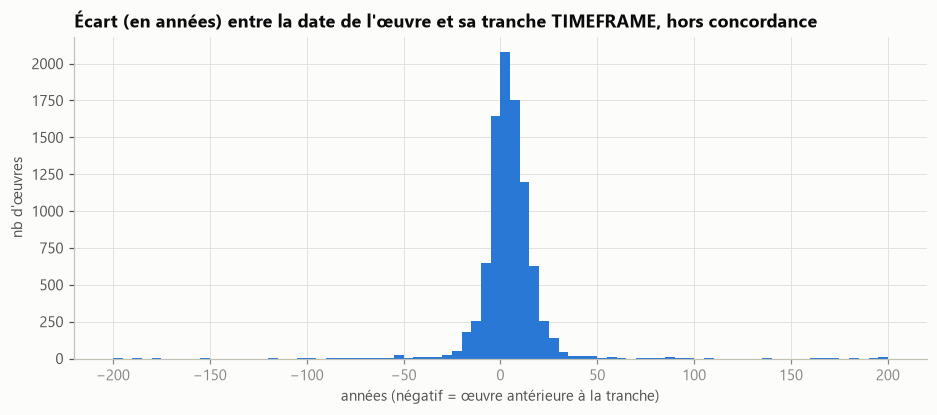

Artistes ayant un seul TIMEFRAME pour toutes leurs œuvres : 97.6%


In [17]:
# Cohérence DATE vs TIMEFRAME : la tranche de 50 ans décrit-elle l'œuvre ou l'artiste ?
d = df.dropna(subset=["YEAR"]).copy()
d["TF_END"] = d["TIMEFRAME"].str.split("-").str[1].astype(int)
d["IN_TF"] = d["YEAR"].between(d["TF_START"], d["TF_END"])
d["ECART_TF"] = np.where(d["YEAR"] < d["TF_START"], d["YEAR"] - d["TF_START"],
                         np.where(d["YEAR"] > d["TF_END"], d["YEAR"] - d["TF_END"], 0))
print(f"Œuvres dont l'année tombe dans le TIMEFRAME : {d['IN_TF'].mean():.1%}")
print(f"Écart médian quand elle en sort : {d.loc[~d['IN_TF'], 'ECART_TF'].abs().median():.0f} ans")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(d.loc[~d["IN_TF"], "ECART_TF"].clip(-200, 200), bins=80, color=MAIN)
ax.set_title("Écart (en années) entre la date de l'œuvre et sa tranche TIMEFRAME, hors concordance")
ax.set_xlabel("années (négatif = œuvre antérieure à la tranche)"); ax.set_ylabel("nb d'œuvres")
save(fig, "03_date_vs_timeframe")
plt.show()

# Hypothèse : TIMEFRAME = période d'activité de l'artiste (identique pour toutes ses œuvres) ?
n_tf = df.groupby("AUTHOR")["TIMEFRAME"].nunique()
print(f"Artistes ayant un seul TIMEFRAME pour toutes leurs œuvres : {(n_tf == 1).mean():.1%}")

**Observations sur les dates**

- Toutes les dates renseignées sont converties en année ; les 9 % restants sont les `-` du brut.
  Un tiers seulement des dates est **exact** : le reste est un intervalle (`1574-88`), une approximation (`c. 1500`),
  une décennie ou un siècle. `YEAR` (milieu de l'intervalle) est donc une estimation.
- Trois dates entières sont **aberrantes dans le brut** (`162628`, `162123`, `11757`) : les deux premières sont des
  intervalles dont le tiret a disparu (1626-28, 1621-23) et sont corrigées ; la troisième est ambiguë et neutralisée.
  Sans cette correction, une seule ligne suffisait à écraser toutes les courbes de densité.
- **`TIMEFRAME` ne décrit pas l'œuvre mais l'artiste** : 97,6 % des artistes ont un unique `TIMEFRAME` pour toute leur
  production. Il s'agit de leur période d'activité principale, ce qui explique que 19 % des œuvres sortent de leur tranche
  (d'une poignée d'années en général). Pour dater une œuvre, `YEAR` est préférable ; `TIMEFRAME` reste utile car il est
  toujours renseigné.

### 4.2 Parsing de `BORN-DIED`

In [18]:
bd = df["BORN-DIED"]
YEAR_Q = r"(?:ca?\.\s*|c\.\s*|about\s*|after\s*|before\s*)?(\d{3,4})"
df["BIRTH_YEAR"] = bd.str.extract(r"\bb[.,]\s*" + YEAR_Q)[0].astype(float)
df["DEATH_YEAR"] = bd.str.extract(r"\bd\.\s*" + YEAR_Q)[0].astype(float)
df["BIRTH_PLACE"] = bd.str.extract(r"\bb[.,][^,]*?\d{3,4}[^,]*,\s*([^,)]+)")[0].str.strip()
df["DEATH_PLACE"] = bd.str.extract(r"\bd\.[^,]*?\d{3,4}[^,]*,\s*([^,)]+)")[0].str.strip()
df.loc[df["DEATH_PLACE"].str.match(r"^(active|documented)", na=False), "DEATH_PLACE"] = np.nan
df["LIFESPAN"] = df["DEATH_YEAR"] - df["BIRTH_YEAR"]

df["BIO_STATUS"] = np.select(
    [df["BIRTH_YEAR"].notna(), bd.str.contains("active", case=False),
     bd.str.contains(r"document|doc\.|known", case=False), bd.str.contains("century", case=False)],
    ["naissance connue", "actif (période)", "documenté", "siècle seulement"], default="autre")

# On raisonne au niveau ARTISTE (et pas œuvre) pour ne pas sur-pondérer les peintres prolifiques
artists = df.drop_duplicates("AUTHOR")
print(f"{len(artists):,} artistes distincts".replace(",", " "))
print(artists["BIO_STATUS"].value_counts(normalize=True).round(3).to_string())
implausible = artists.loc[(artists["LIFESPAN"] < 15) | (artists["LIFESPAN"] > 100),
                          ["AUTHOR", "BORN-DIED", "BIRTH_YEAR", "DEATH_YEAR", "LIFESPAN"]]
print(f"\nDurées de vie invraisemblables (< 15 ou > 100 ans) -> erreurs de saisie, neutralisées :")
implausible

5 767 artistes distincts
BIO_STATUS
naissance connue    0.842
actif (période)     0.127
autre               0.023
documenté           0.006
siècle seulement    0.002

Durées de vie invraisemblables (< 15 ou > 100 ans) -> erreurs de saisie, neutralisées :


,AUTHOR,BORN-DIED,BIRTH_YEAR,DEATH_YEAR,LIFESPAN
1395,"ANTOINE, Jacques-Denis","(b. 1733, Paris, d. 19801, Paris)",1733.0,1980.0,247.0
1416,"ANTONELLI, Alessandro","(b. 1798, Ghemme, d. 1788, Maggiora)",1798.0,1788.0,-10.0
10720,"CISERI, Antonio","(b. 1821, Ronco Scrivia, d. 1933, Firenze)",1821.0,1933.0,112.0


In [19]:
# Neutralisation des dates biographiques incohérentes (conservées en brut dans BORN-DIED)
bad_bio = (df["LIFESPAN"] < 15) | (df["LIFESPAN"] > 100)
df.loc[bad_bio, ["BIRTH_YEAR", "DEATH_YEAR", "LIFESPAN"]] = np.nan
artists = df.drop_duplicates("AUTHOR")
print(f"{bad_bio.sum()} lignes corrigées ; durée de vie médiane : {artists['LIFESPAN'].median():.0f} ans "
      f"(min {artists['LIFESPAN'].min():.0f}, max {artists['LIFESPAN'].max():.0f})")

11 lignes corrigées ; durée de vie médiane : 66 ans (min 19, max 100)


**Observations sur `BORN-DIED`** — 84 % des artistes ont une année de naissance connue ; les autres, surtout médiévaux,
ne sont connus que par une période d'activité (`active 1302-1340 in Florence`) ou un siècle. Le parsing révèle
des **erreurs de saisie** dans le brut : décès en `19801`, décès avant la naissance, durée de vie de 112 ans.
Ces valeurs sont neutralisées (la chaîne brute est conservée).

### 4.3 Parsing de `TECHNIQUE` : médium, support et dimensions

In [20]:
tech = df["TECHNIQUE"]
df["MEDIUM"] = tech.str.split(", ").str[0].str.strip()     # ', ' : évite de couper '213,4'


def medium_family(m):
    m = m.lower()
    if "fresco" in m:
        return "Fresque"
    if "oil" in m and "tempera" in m:
        return "Huile + tempera"
    if "oil" in m:
        return "Huile"
    if "tempera" in m:
        return "Tempera"
    if re.search(r"pastel|watercolo|gouache|chalk|pencil|ink|charcoal", m):
        return "Techniques sur papier"
    if re.match(r"^(panel|wood|oak|poplar|limewood|canvas|pine|walnut)\b", m):
        return "Non précisé (support seul)"
    return "Autre"


df["MEDIUM_FAMILY"] = df["MEDIUM"].map(medium_family)

sup = df["MEDIUM"].str.lower().str.extract(r"\bon\s+(.+)$")[0].fillna(df["MEDIUM"].str.lower())
df["SUPPORT"] = np.select(
    [sup.str.contains("canvas"), sup.str.contains(r"panel|wood|oak|poplar|lime|pine|walnut|beech"),
     sup.str.contains("copper|tin|metal|silver|zinc"), sup.str.contains("paper|cardboard|parchment|vellum"),
     sup.str.contains(r"plaster|wall|fresco")],
    ["Toile", "Bois / panneau", "Métal (cuivre…)", "Papier / carton", "Mur / plâtre"], default="Autre / inconnu")

# Dimensions « H x L unité » (convention WGA : hauteur × largeur), décimale '.' ou ','
num = r"(\d+(?:[.,]\d+)?)"
# 3e dimension optionnelle (épaisseur des fresques détachées : « 116 x 75 x 2 cm »)
dims = tech.str.extract(num + r"\s*x\s*" + num + r"(?:\s*x\s*\d+(?:[.,]\d+)?)?\s*(cm|mm|m)\b")
factor = dims[2].map({"cm": 1, "mm": 0.1, "m": 100})
df["HEIGHT_CM"] = dims[0].str.replace(",", ".").astype(float) * factor
df["WIDTH_CM"] = dims[1].str.replace(",", ".").astype(float) * factor
# Tondi (tableaux ronds) : « diameter 80 cm »
diam = tech.str.extract(r"diam(?:eter|\.)\s*" + num + r"\s*(cm|mm|m)\b", flags=re.I)
is_tondo = diam[0].notna() & df["HEIGHT_CM"].isna()
diam_cm = diam[0].str.replace(",", ".").astype(float) * diam[1].map({"cm": 1, "mm": 0.1, "m": 100})
df.loc[is_tondo, ["HEIGHT_CM", "WIDTH_CM"]] = np.c_[diam_cm[is_tondo], diam_cm[is_tondo]]
df["IS_TONDO"] = is_tondo

df["ASPECT"] = df["WIDTH_CM"] / df["HEIGHT_CM"]
df["SURFACE_M2"] = df["WIDTH_CM"] * df["HEIGHT_CM"] / 1e4
df["ORIENTATION"] = pd.cut(df["ASPECT"], [0, 0.95, 1.05, np.inf], labels=["Portrait (vertical)", "Carré", "Paysage (horizontal)"])

print(f"Dimensions extraites : {df['HEIGHT_CM'].notna().mean():.1%} des œuvres "
      f"(dont {is_tondo.sum()} tondi via le diamètre)")
print("Unités rencontrées :", dims[2].value_counts().to_dict())
df.loc[df["HEIGHT_CM"].notna(), ["TECHNIQUE", "MEDIUM", "MEDIUM_FAMILY", "SUPPORT", "HEIGHT_CM", "WIDTH_CM", "ASPECT"]].sample(8, random_state=3)

Dimensions extraites : 53.8% des œuvres (dont 512 tondi via le diamètre)
Unités rencontrées : {'cm': 23990, 'mm': 3951, 'm': 12}


,TECHNIQUE,MEDIUM,MEDIUM_FAMILY,SUPPORT,HEIGHT_CM,WIDTH_CM,ASPECT
33102,"Manuscript (Codex Pal. Germ. 848), 355 x 250 mm",Manuscript (Codex Pal. Germ. 848),Autre,Autre / inconnu,35.5,25.0,0.704225
49461,"Oil on canvas, 49 x 73 cm",Oil on canvas,Huile,Toile,49.0,73.0,1.489796
27145,"Oil on canvas, 50 x 62 cm",Oil on canvas,Huile,Toile,50.0,62.0,1.240000
32283,"Manuscript (Ms. 1171), 270 x 220 mm",Manuscript (Ms. 1171),Autre,Autre / inconnu,27.0,22.0,0.814815
35370,"Oil on panel, 27 x 35 cm",Oil on panel,Huile,Bois / panneau,27.0,35.0,1.296296
43473,"Oil on wood, 42 x 34 cm",Oil on wood,Huile,Bois / panneau,42.0,34.0,0.809524
4431,"Oil on canvas, 139 x 129 cm",Oil on canvas,Huile,Toile,139.0,129.0,0.928058
17324,"Oil on canvas, 34,5 x 48,3 cm",Oil on canvas,Huile,Toile,34.5,48.3,1.400000


### 4.4 Titre, localisation et URL de l'image

In [21]:
df["IS_DETAIL"] = df["TITLE"].str.contains(r"\bdetail", case=False)
# Titre « de base » sans les parenthèses finales : '(detail)', '(central panel)', '(left wing)'…
df["TITLE_BASE"] = df["TITLE"].str.replace(r"\s*\([^)]*\)\s*$", "", regex=True).str.strip()

df["IS_PRIVATE"] = df["LOCATION"].str.contains("private collection", case=False)
df["CITY"] = df["LOCATION"].str.split(", ").str[-1].str.strip()
df.loc[df["IS_PRIVATE"] | df["LOCATION"].eq("-"), "CITY"] = np.nan

# Sur la WGA, l'image est servie sous /art/ avec la même arborescence que la page /html/
df["IMAGE_URL"] = df["URL"].str.replace("/html/", "/art/", regex=False).str.replace(r"\.html$", ".jpg", regex=True)
df[["URL", "IMAGE_URL"]].head(3)

,URL,IMAGE_URL
0,https://www.wga.hu/html/a/aachen/adonis.html,https://www.wga.hu/art/a/aachen/adonis.jpg
1,https://www.wga.hu/html/a/aachen/allegory.html,https://www.wga.hu/art/a/aachen/allegory.jpg
2,https://www.wga.hu/html/a/aachen/allegorz.html,https://www.wga.hu/art/a/aachen/allegorz.jpg


**Bilan du feature engineering** — les dimensions n'apparaissent que dans ~54 % des techniques du catalogue complet
(70 % pour les peintures), en cm, mm (manuscrits) ou m. Le parsing gère la virgule décimale (`213,4 x 152,4 cm`),
la troisième dimension des fresques détachées (`116 x 75 x 2 cm`) et les **tondi** (`diameter 80 cm`).

Une limite demeure : pour les détails de prédelle, les dimensions indiquées sont celles de **l'ensemble**
(`23 x 230 cm (entire predella)`), pas du fragment photographié. Leur ratio d'aspect est donc trompeur.

## 5. Focus sur les peintures — la cible du GAN

À partir d'ici on travaille sur le sous-ensemble `FORM == "painting"`.

In [22]:
P = df[df["FORM"] == "painting"].copy()
n = len(P)
kpi = pd.DataFrame([
    ("Peintures", n, f"{n / len(df):.1%} du catalogue"),
    ("Artistes", P["AUTHOR"].nunique(), ""),
    ("Écoles", P["SCHOOL"].nunique(), ""),
    ("Genres (TYPE)", P["TYPE"].nunique(), ""),
    ("Lieux de conservation", P["LOCATION"].nunique(), ""),
    ("Datées", int(P["YEAR"].notna().sum()), f"{P['YEAR'].notna().mean():.1%} des peintures"),
    ("Avec dimensions", int(P["HEIGHT_CM"].notna().sum()), f"{P['HEIGHT_CM'].notna().mean():.1%} des peintures"),
    ("Titres « (detail) »", int(P["IS_DETAIL"].sum()), f"{P['IS_DETAIL'].mean():.1%} des peintures"),
], columns=["indicateur", "valeur", "part"]).set_index("indicateur")
kpi

,valeur,part
indicateur,,
Peintures,32438,61.4% du catalogue
Artistes,3663,
Écoles,26,
Genres (TYPE),10,
Lieux de conservation,2284,
Datées,28549,88.0% des peintures
Avec dimensions,22878,70.5% des peintures
Titres « (detail) »,5056,15.6% des peintures


### 5.1 Genres (`TYPE`)

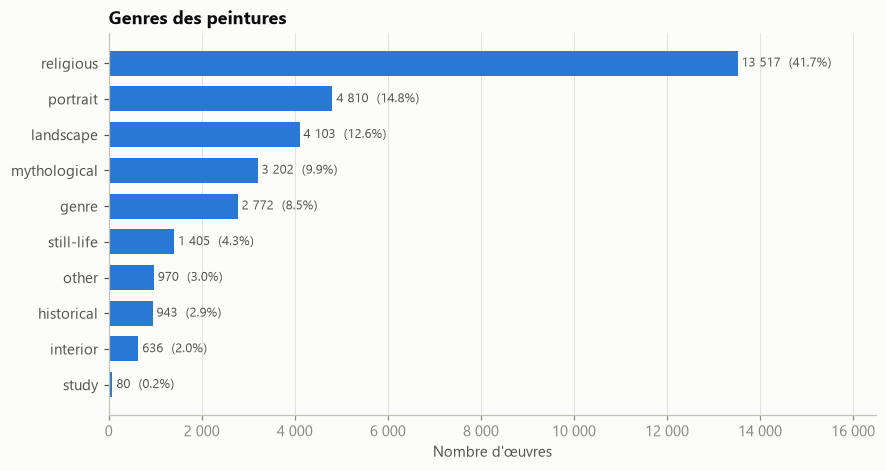

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
barh(P["TYPE"].value_counts(), "Genres des peintures", ax=ax)
save(fig, "04_paintings_type")
plt.show()

**Observations** — la peinture **religieuse** représente 42 % des peintures, loin devant le portrait (15 %) et le paysage
(13 %). Les genres « profanes » plus rares (nature morte, intérieur, scène historique) pèsent chacun moins de 5 %.
La modalité `study` (études) est quasi inexistante.

### 5.2 Écoles (`SCHOOL`) et concentration

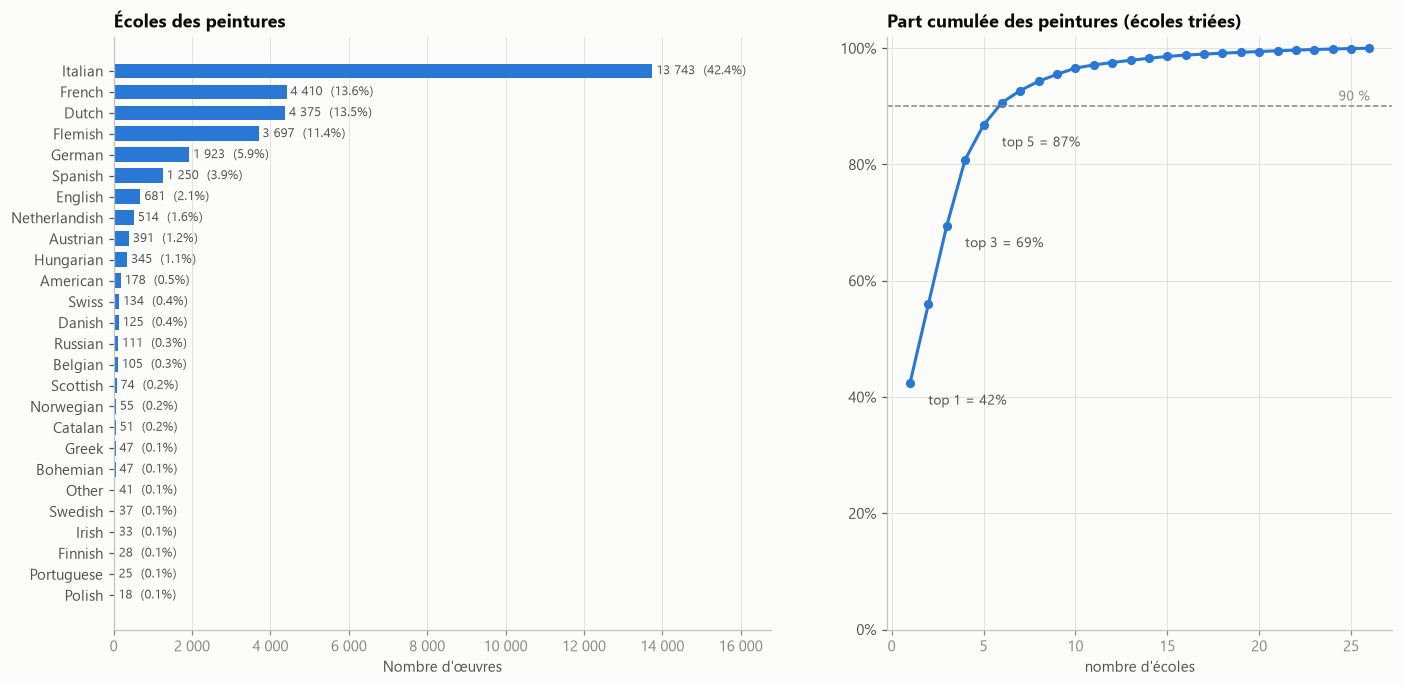

In [44]:
sc = P["SCHOOL"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.3, 1]})
barh(sc, "Écoles des peintures", ax=axes[0])

cum = sc.cumsum() / sc.sum()
axes[1].plot(range(1, len(cum) + 1), cum.values, color=MAIN, marker="o", markersize=5)
for k in (1, 3, 5):
    axes[1].annotate(f"top {k} = {cum.iloc[k - 1]:.0%}", (k, cum.iloc[k - 1]), xytext=(12, -14),
                     textcoords="offset points", fontsize=9, color=INK2)
axes[1].axhline(0.9, color=MUTED, lw=1, ls="--")
axes[1].text(len(cum), 0.91, "90 %", ha="right", color=MUTED, fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Part cumulée des peintures (écoles triées)")
axes[1].set_xlabel("nombre d'écoles"); axes[1].set_ylim(0, 1.02)
save(fig, "05_paintings_school")
plt.show()

**Observations** — l'**école italienne** concentre à elle seule 42 % des peintures. Les trois premières écoles
(italienne, française, hollandaise) en couvrent 69 %, les cinq premières 87 %. Au-delà de la 10ᵉ, chaque école pèse
moins de 1 % : le catalogue est celui de la peinture d'Europe occidentale. Les écoles « Flemish » et « Netherlandish »
se recoupent historiquement (Pays-Bas méridionaux avant et après 1600) : un regroupement serait défendable.

### 5.3 Dimension temporelle

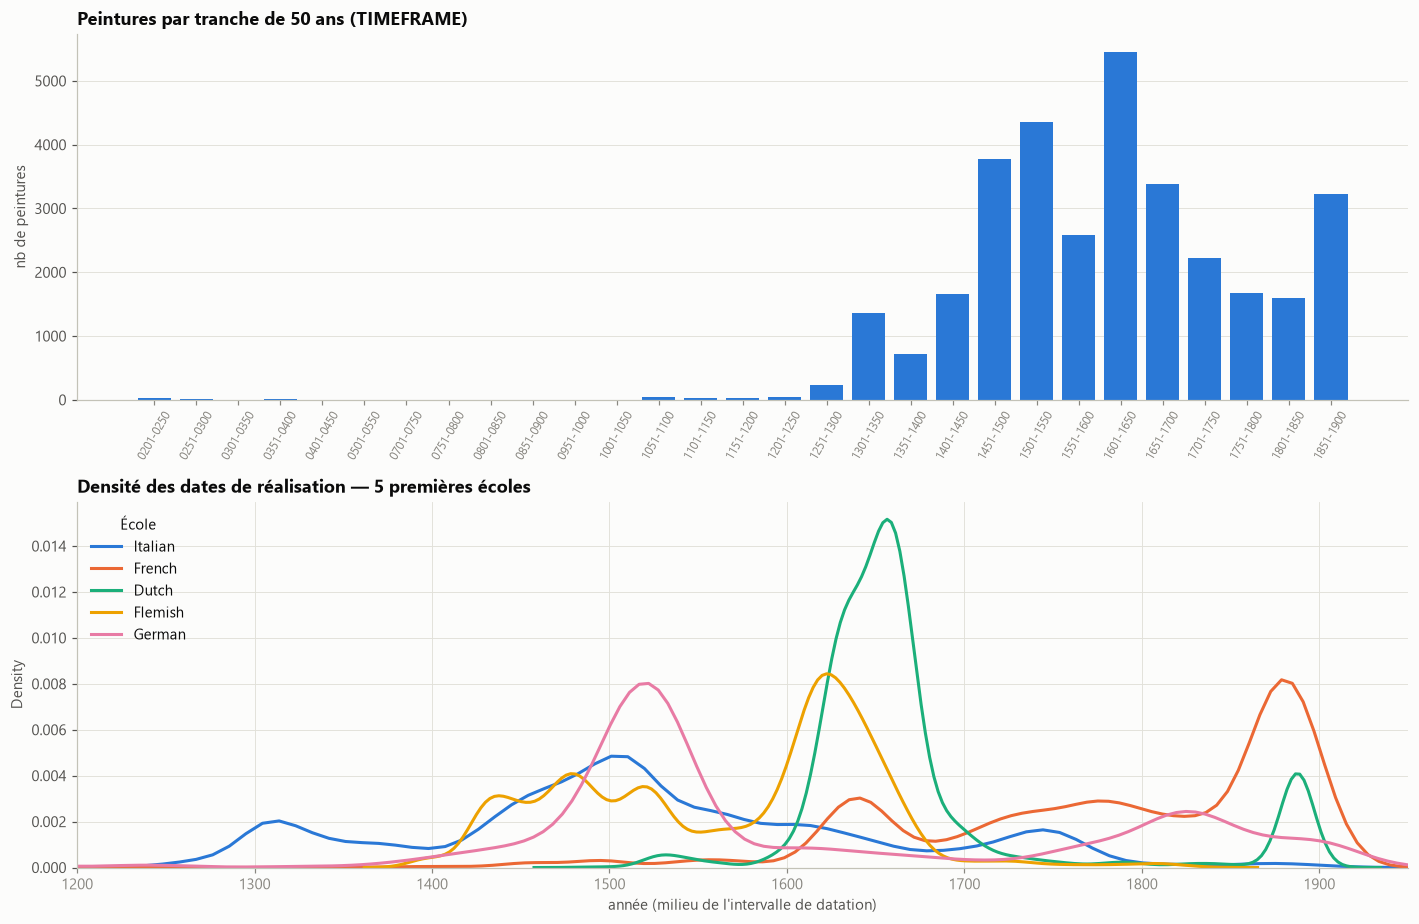

count    28549.0
mean      1607.0
std        173.0
min        150.0
25%       1500.0
50%       1613.0
75%       1724.0
max       1929.0


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.5))

tf = P["TIMEFRAME"].value_counts().sort_index()
axes[0].bar(tf.index, tf.values, color=MAIN, width=0.8)
axes[0].set_title("Peintures par tranche de 50 ans (TIMEFRAME)")
axes[0].tick_params(axis="x", rotation=60, labelsize=8); axes[0].grid(axis="x", visible=False)
axes[0].set_ylabel("nb de peintures")

top_sc = P["SCHOOL"].value_counts().index[:5]
for i, s in enumerate(top_sc):
    sns.kdeplot(P.loc[P["SCHOOL"] == s, "YEAR"].dropna(), ax=axes[1], color=CAT[i], label=s, bw_adjust=0.6, lw=2)
axes[1].set_title("Densité des dates de réalisation — 5 premières écoles")
axes[1].set_xlabel("année (milieu de l'intervalle de datation)"); axes[1].set_xlim(1200, 1950)
axes[1].legend(title="École", loc="upper left")
plt.tight_layout()
save(fig, "06_paintings_time")
plt.show()

print(P["YEAR"].describe().round(0).to_string())

**Observations**

- Le catalogue **s'arrête en 1900** et la peinture n'y devient massive qu'à partir du XIVᵉ siècle. Le pic se situe
  en 1601-1650 (Baroque, Siècle d'or hollandais). La moitié des peintures datées est antérieure à 1613.
- Chaque école a son **âge d'or**, nettement décalé : l'Italie autour de 1500 (Renaissance) avec un premier pic
  vers 1310 (Giotto), l'Allemagne vers 1520 (Dürer, Cranach), la Flandre vers 1620 (Rubens), la Hollande vers 1650
  (Rembrandt, Vermeer), la France vers 1880 (impressionnisme). Le second pic hollandais vers 1885 correspond à
  **Van Gogh**, classé école hollandaise.
- Conséquence : école et époque sont **confondues**. Un GAN entraîné sur « l'école française » apprendra surtout
  l'impressionnisme.

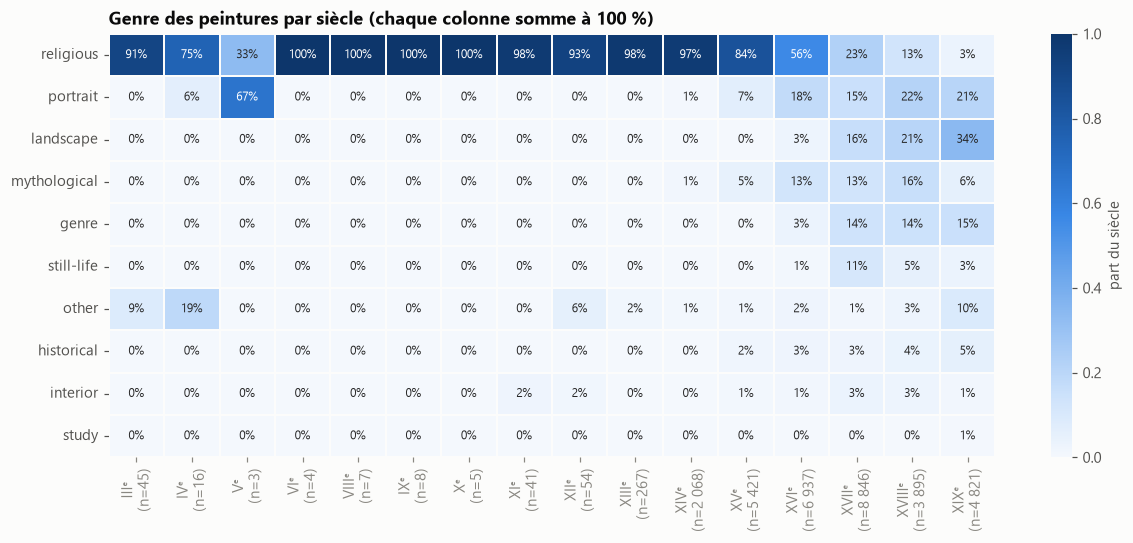

In [26]:
# Genre × siècle : le sujet des peintures évolue-t-il ?
P["CENTURY_LBL"] = P["CENTURY"].map(lambda c: f"{roman(c)}ᵉ")
order_c = [f"{roman(c)}ᵉ" for c in sorted(P["CENTURY"].unique())]
ct = pd.crosstab(P["TYPE"], P["CENTURY_LBL"], normalize="columns")[order_c]
ct = ct.loc[P["TYPE"].value_counts().index]
counts_c = P["CENTURY_LBL"].value_counts()[order_c]
ct.columns = [f"{c}\n(n={counts_c[c]:,})".replace(",", " ") for c in order_c]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(ct, cmap=SEQ, annot=True, fmt=".0%", annot_kws={"size": 8}, linewidths=1, linecolor=SURFACE,
            cbar_kws={"label": "part du siècle"}, ax=ax)
ax.set_title("Genre des peintures par siècle (chaque colonne somme à 100 %)")
ax.set_xlabel(""); ax.set_ylabel("")
save(fig, "07_type_by_century")
plt.show()

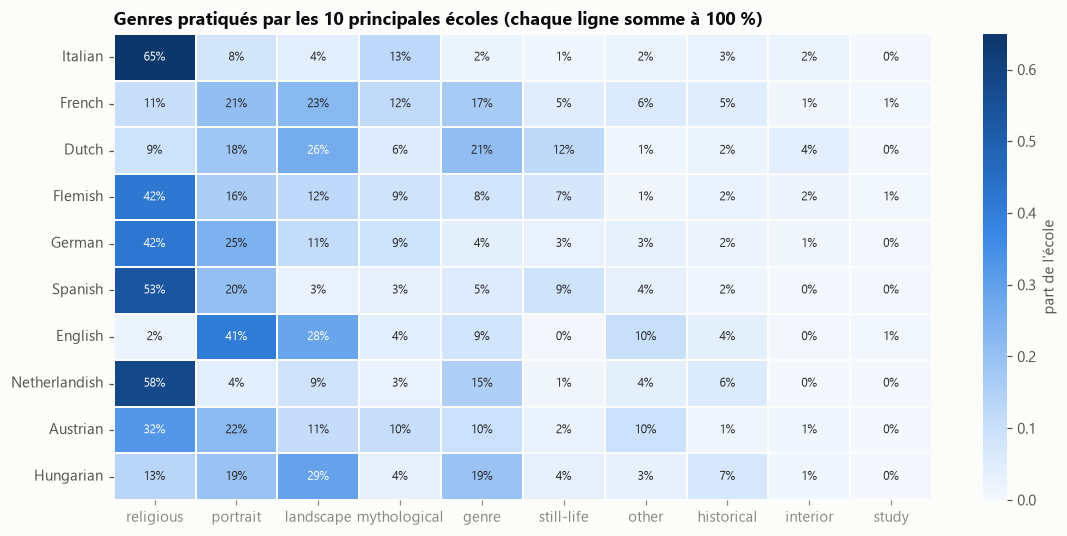

In [27]:
# École × genre : chaque école a-t-elle sa spécialité ?
top10 = P["SCHOOL"].value_counts().index[:10]
ct = pd.crosstab(P.loc[P["SCHOOL"].isin(top10), "SCHOOL"], P["TYPE"], normalize="index").loc[top10]
ct = ct[P["TYPE"].value_counts().index]
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(ct, cmap=SEQ, annot=True, fmt=".0%", annot_kws={"size": 8}, linewidths=1, linecolor=SURFACE,
            cbar_kws={"label": "part de l'école"}, ax=ax)
ax.set_title("Genres pratiqués par les 10 principales écoles (chaque ligne somme à 100 %)")
ax.set_xlabel(""); ax.set_ylabel("")
save(fig, "08_school_by_type")
plt.show()

**Observations**

- **Jusqu'au XIVᵉ siècle, la peinture est presque exclusivement religieuse** (> 95 % des œuvres), et l'est encore
  à 84 % au XVᵉ. Le basculement a lieu au XVIᵉ (56 %) puis au XVIIᵉ (23 %) ; au XIXᵉ, la peinture religieuse ne représente plus que 3 % et le **paysage**
  devient le premier genre (34 %). (Les siècles antérieurs au XIIIᵉ comptent quelques dizaines d'œuvres : les
  pourcentages y sont peu significatifs.)
- Les spécialités par école sont marquées : l'Italie est majoritairement religieuse, la Hollande surreprésente la
  **scène de genre, le paysage et la nature morte** (peinture de marché protestante), l'Angleterre le **portrait**.

### 5.4 Techniques et supports

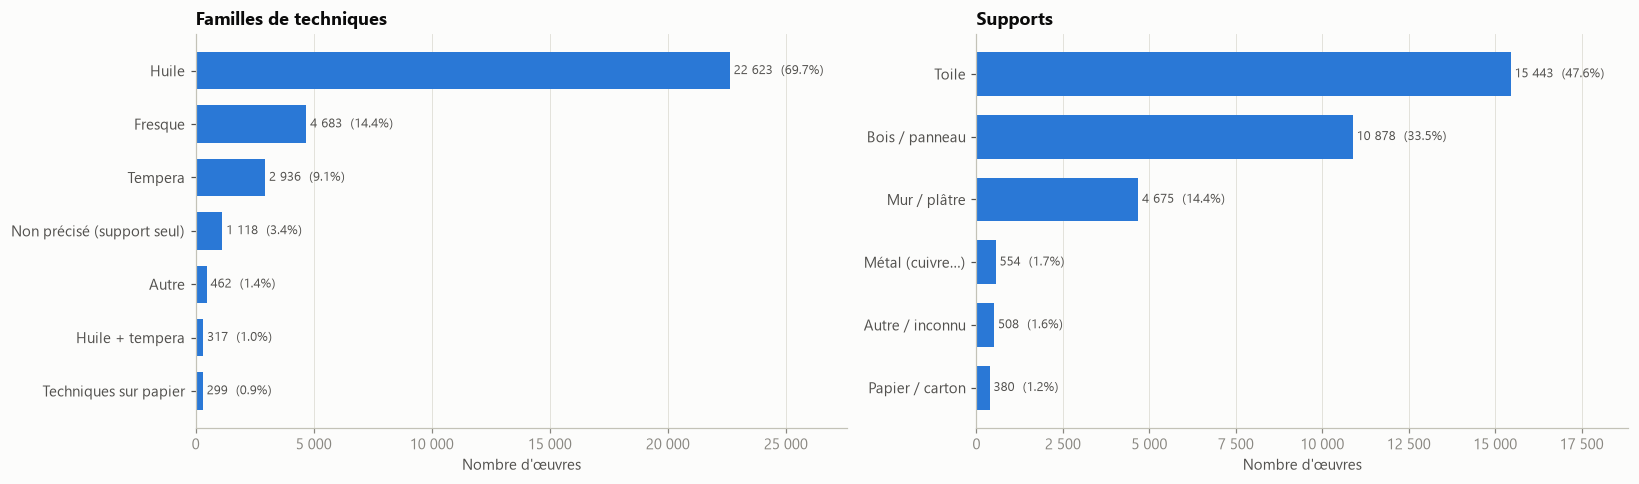

20 techniques brutes les plus fréquentes :


,nb
MEDIUM,
Oil on canvas,14726
Fresco,4488
Oil on panel,3332
Oil on wood,1942
Tempera on wood,1167
Tempera on panel,807
Oil on oak panel,773
Panel,553
Oil on copper,476


In [28]:
FAM_ORDER = ["Huile", "Tempera", "Fresque", "Huile + tempera", "Techniques sur papier", "Non précisé (support seul)", "Autre"]
FAM_COLORS = dict(zip(FAM_ORDER, CAT[:5] + [OTHER, MUTED]))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
barh(P["MEDIUM_FAMILY"].value_counts(), "Familles de techniques", ax=axes[0])
barh(P["SUPPORT"].value_counts(), "Supports", ax=axes[1])
plt.tight_layout()
save(fig, "09_medium_support")
plt.show()

print("20 techniques brutes les plus fréquentes :")
P["MEDIUM"].value_counts().head(20).to_frame("nb")

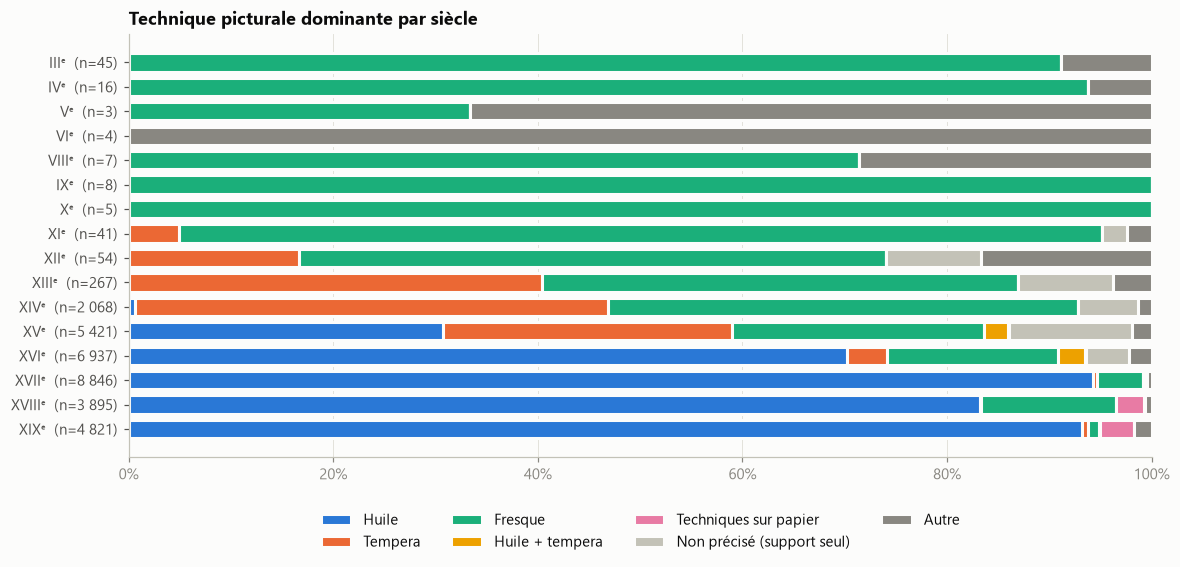

In [29]:
# Évolution des techniques dans le temps : barres 100 % empilées par siècle
ct = pd.crosstab(P["CENTURY_LBL"], P["MEDIUM_FAMILY"], normalize="index").loc[order_c]
ct = ct[[f for f in FAM_ORDER if f in ct.columns]]
ct.index = [f"{c}  (n={counts_c[c]:,})".replace(",", " ") for c in ct.index]

fig, ax = plt.subplots(figsize=(12, 5))
left = np.zeros(len(ct))
for fam in ct.columns:
    ax.barh(ct.index, ct[fam], left=left, color=FAM_COLORS[fam], label=fam, height=0.75,
            edgecolor=SURFACE, linewidth=2)
    left += ct[fam].values
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Technique picturale dominante par siècle")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
save(fig, "10_medium_by_century")
plt.show()

**Observations**

- L'**huile** domine (70 % des peintures), suivie de la **fresque** (14 %) et de la **tempera** (9 %). Les supports
  suivent : toile (48 %), bois (34 %), mur (14 %).
- La chronologie est celle de l'histoire de l'art : **fresque et tempera** au Moyen Âge et au Trecento (plus de 85 %
  des peintures des XIIIᵉ-XIVᵉ siècles), transition au XVᵉ, huile majoritaire dès le XVIᵉ (70 %) puis quasi exclusive
  ensuite (83 à 94 % selon le siècle, le reste étant surtout des fresques décoratives baroques).
- Pour le GAN, la technique a un impact visuel direct : fonds dorés et aplats de la tempera, texture murale et
  lacunes des fresques, empâtements et vernis de l'huile. Un corpus mêlant les trois donnera des générations
  hybrides.

### 5.5 Dimensions et format des tableaux

C'est la section la plus directement utile au preprocessing : un GAN classique (DCGAN) travaille sur des
**images carrées** (64×64, 128×128). Le **ratio largeur / hauteur** des tableaux détermine ce que l'on perdra
au recadrage.

In [30]:
Pd = P.dropna(subset=["ASPECT"])
Pd = Pd[(Pd["HEIGHT_CM"].between(1, 3000)) & (Pd["WIDTH_CM"].between(1, 3000))]
print(f"{len(Pd):,} peintures avec des dimensions exploitables ({len(Pd) / len(P):.1%})".replace(",", " "))
Pd[["HEIGHT_CM", "WIDTH_CM", "SURFACE_M2", "ASPECT"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(2)

22 872 peintures avec des dimensions exploitables (70.5%)


,HEIGHT_CM,WIDTH_CM,SURFACE_M2,ASPECT
count,22872.00,22872.00,22872.00,22872.00
mean,105.99,104.01,1.85,1.04
std,99.94,101.42,6.88,0.62
min,1.90,1.60,0.00,0.06
5%,26.00,24.00,0.07,0.54
25%,50.00,48.00,0.25,0.75
50%,79.00,77.00,0.61,0.86
75%,128.00,129.00,1.60,1.31
95%,267.00,258.00,6.27,1.68
max,2700.00,3000.00,435.00,51.10


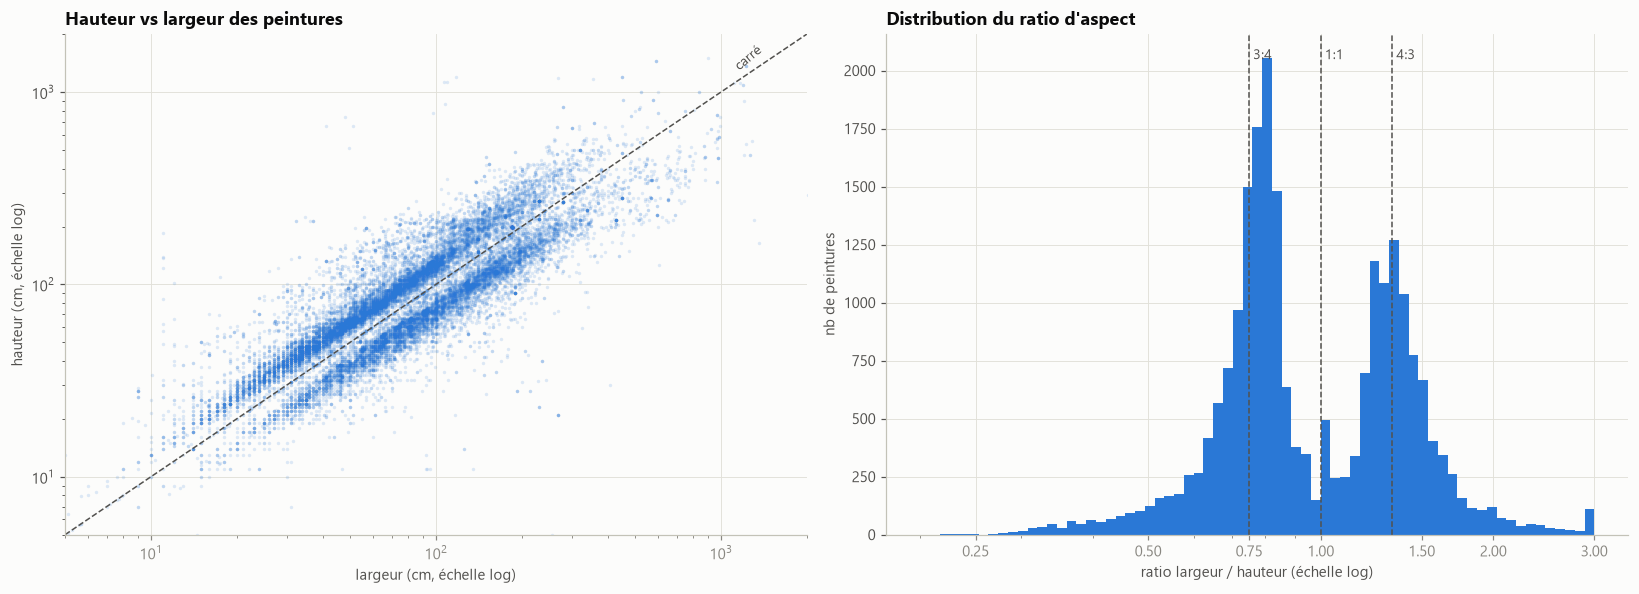

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.scatter(Pd["WIDTH_CM"], Pd["HEIGHT_CM"], s=5, alpha=0.15, color=MAIN, linewidths=0)
lim = [5, 2000]
ax.plot(lim, lim, color=INK2, lw=1, ls="--")
ax.text(1100, 1300, "carré", color=INK2, fontsize=9, rotation=40)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("largeur (cm, échelle log)"); ax.set_ylabel("hauteur (cm, échelle log)")
ax.set_title("Hauteur vs largeur des peintures")

ax = axes[1]
ax.hist(Pd["ASPECT"].clip(0.2, 3), bins=np.logspace(np.log10(0.2), np.log10(3), 70), color=MAIN)
ax.set_xscale("log")
for r, lbl in [(3 / 4, "3:4"), (1, "1:1"), (4 / 3, "4:3")]:
    ax.axvline(r, color=INK2, lw=1, ls="--")
    ax.text(r, ax.get_ylim()[1] * 0.95, f" {lbl}", color=INK2, fontsize=9)
ax.set_xticks([0.25, 0.5, 0.75, 1, 1.5, 2, 3]); ax.xaxis.set_major_formatter(mtick.ScalarFormatter())
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_xlabel("ratio largeur / hauteur (échelle log)"); ax.set_ylabel("nb de peintures")
ax.set_title("Distribution du ratio d'aspect")
plt.tight_layout()
save(fig, "11_dimensions")
plt.show()

In [32]:
# Perte d'information d'un recadrage centré en carré : 1 - min(r, 1/r)
Pd = Pd.assign(CROP_LOSS=1 - np.minimum(Pd["ASPECT"], 1 / Pd["ASPECT"]))
bins = pd.cut(Pd["CROP_LOSS"], [-0.01, 0.1, 0.25, 0.4, 1], labels=["< 10 %", "10-25 %", "25-40 %", "> 40 %"])
print("Part de l'image perdue par un recadrage centré en carré :")
print(bins.value_counts(normalize=True).sort_index().map("{:.1%}".format).to_string())
print(f"\nPerte médiane : {Pd['CROP_LOSS'].median():.1%}")
print("\nOrientation des tableaux :")
print(Pd["ORIENTATION"].value_counts(normalize=True).map("{:.1%}".format).to_string())

Part de l'image perdue par un recadrage centré en carré :
CROP_LOSS
< 10 %      7.2%
10-25 %    46.3%
25-40 %    34.3%
> 40 %     12.2%

Perte médiane : 24.4%

Orientation des tableaux :
ORIENTATION
Portrait (vertical)     55.3%
Paysage (horizontal)    41.1%
Carré                    3.6%


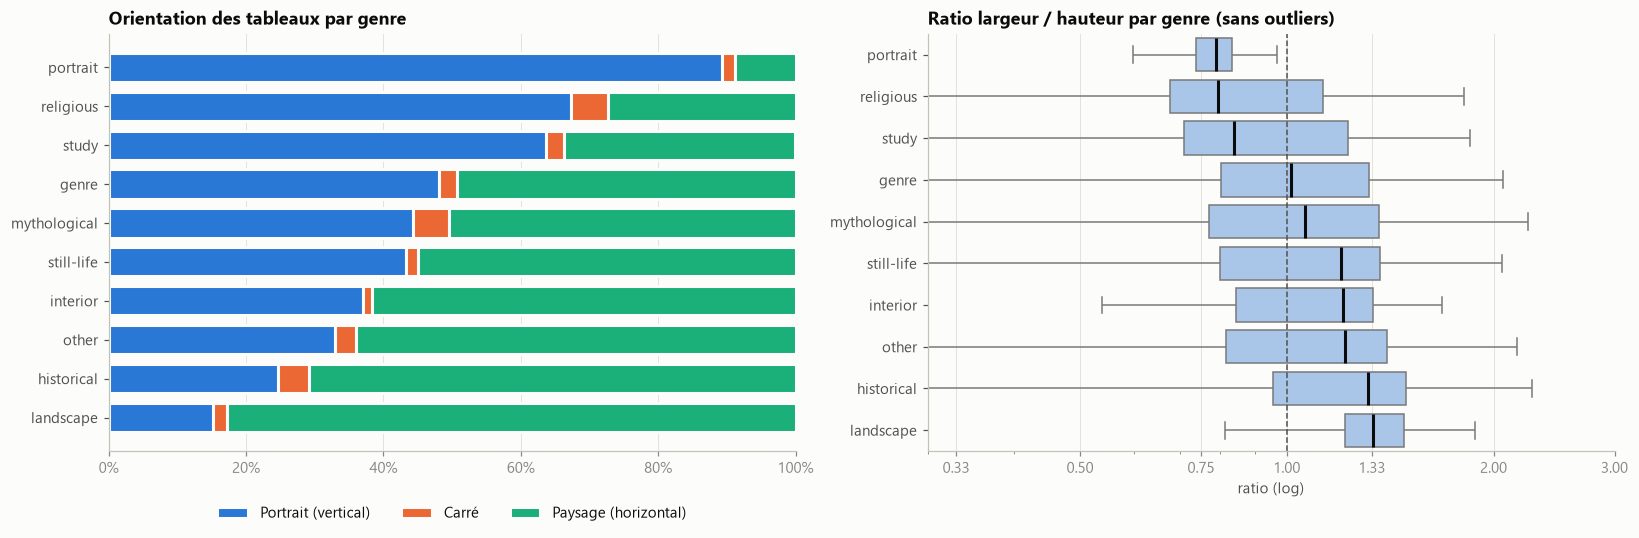

Kruskal-Wallis (ratio ~ genre) : H = 5010, p = 0.0e+00 -> le format dépend significativement du genre


In [33]:
# Orientation et ratio selon le genre
ORI_COLORS = dict(zip(["Portrait (vertical)", "Carré", "Paysage (horizontal)"], CAT[:3]))
ct = pd.crosstab(Pd["TYPE"], Pd["ORIENTATION"], normalize="index")
ct = ct.sort_values("Portrait (vertical)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
left = np.zeros(len(ct))
for o in ct.columns:
    axes[0].barh(ct.index, ct[o], left=left, color=ORI_COLORS[o], label=o, height=0.75, edgecolor=SURFACE, linewidth=2)
    left += ct[o].values
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[0].set_xlim(0, 1)
axes[0].grid(axis="y", visible=False)
axes[0].set_title("Orientation des tableaux par genre")
axes[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))

order_t = Pd.groupby("TYPE")["ASPECT"].median().sort_values().index
sns.boxplot(data=Pd, y="TYPE", x="ASPECT", order=order_t, ax=axes[1], color="#9ec5f4",
            showfliers=False, linewidth=1, medianprops={"color": INK, "linewidth": 2})
axes[1].axvline(1, color=INK2, ls="--", lw=1)
axes[1].set_xscale("log"); axes[1].set_xlim(0.3, 3)
axes[1].set_xticks([0.33, 0.5, 0.75, 1, 1.33, 2, 3]); axes[1].xaxis.set_major_formatter(mtick.ScalarFormatter())
axes[1].xaxis.set_minor_formatter(mtick.NullFormatter())
axes[1].set_title("Ratio largeur / hauteur par genre (sans outliers)"); axes[1].set_ylabel(""); axes[1].set_xlabel("ratio (log)")
plt.tight_layout()
save(fig, "12_orientation_by_type")
plt.show()

groups = [g["ASPECT"].values for _, g in Pd.groupby("TYPE")]
h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis (ratio ~ genre) : H = {h:.0f}, p = {p:.1e} -> le format dépend significativement du genre")

**Observations — les plus importantes pour le preprocessing**

- La distribution du ratio est **bimodale**, avec deux pics nets autour de **0,8** (vertical, ≈ 4:5) et **1,3**
  (horizontal, ≈ 4:3). Les tableaux carrés ne représentent que 3,6 %. Le nuage hauteur/largeur montre les deux
  mêmes bandes parallèles à la diagonale.
- 55 % des tableaux sont verticaux, 41 % horizontaux. Un **recadrage centré en carré** fait perdre en médiane
  **24 % de la surface** du tableau, et plus de 40 % pour une œuvre sur huit.
- Le format dépend fortement du genre (Kruskal-Wallis, p ≈ 0) : **89 % des portraits sont verticaux**, 83 % des
  paysages horizontaux. Un recadrage centré coupera donc systématiquement le haut et le bas des portraits
  (têtes, mains) et les bords des paysages.
- Les ratios extrêmes (> 5) sont surtout des **prédelles** (panneaux très allongés au bas des retables),
  plus quelques erreurs de saisie probables (`102 x 12 cm`).

### 5.6 Artistes : une distribution à longue traîne

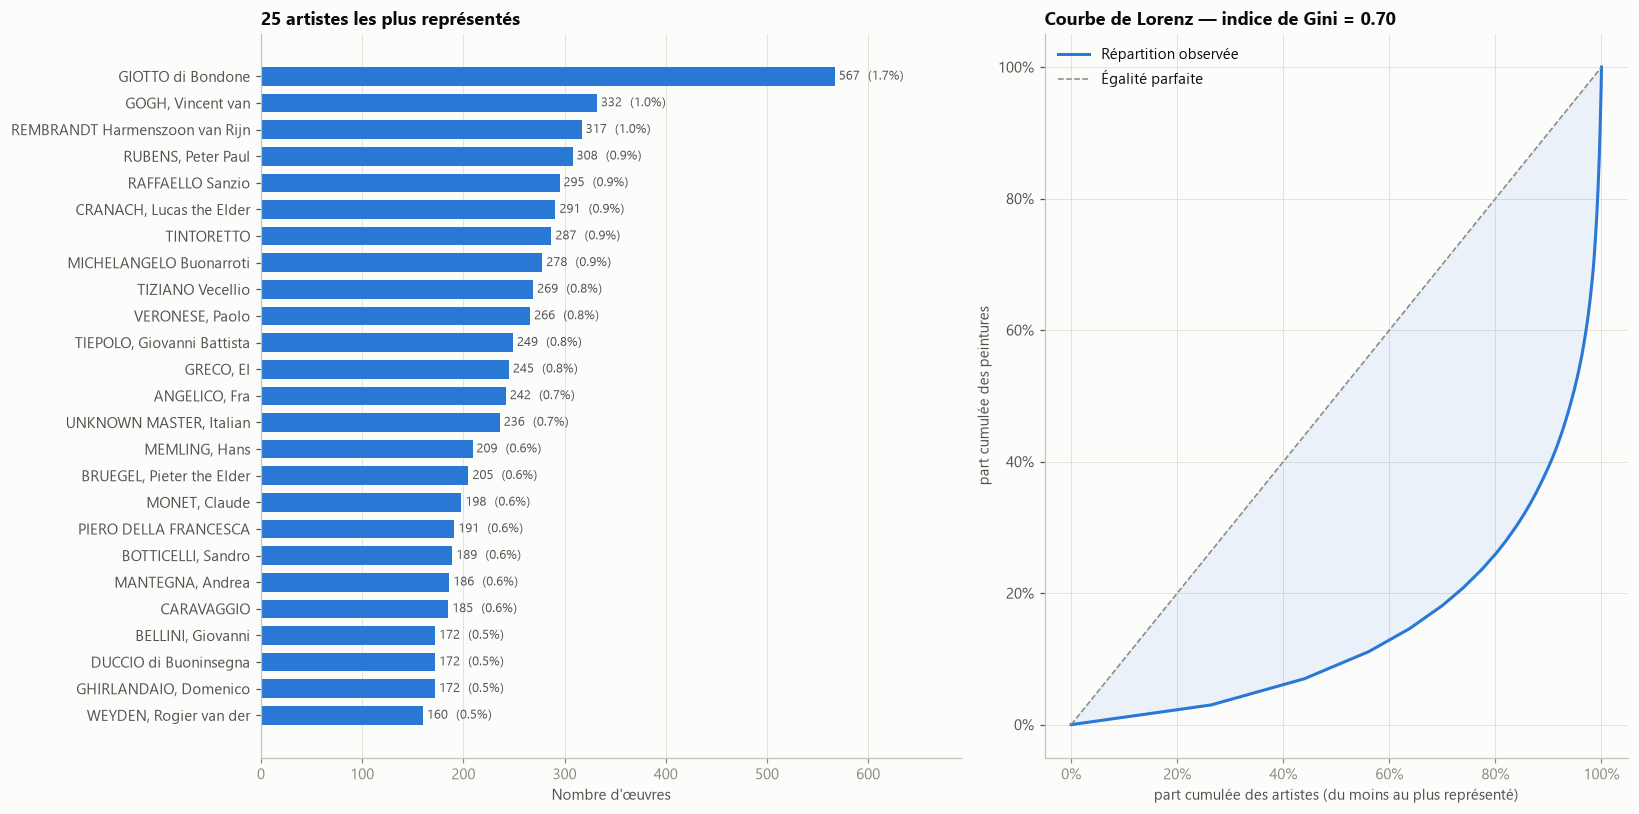

3 663 peintres ; médiane = 3 œuvre(s) par peintre
Peintres représentés par une seule œuvre : 962 (26.3%)
Les 1 % de peintres les plus représentés = 24.3% des peintures ; les 10 % = 60.9%
Anonymes (UNKNOWN MASTER) : 618 peintures


In [34]:
au = P["AUTHOR"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), gridspec_kw={"width_ratios": [1.2, 1]})
barh(au.head(25), "25 artistes les plus représentés", ax=axes[0], pct_of=n)

# Courbe de Lorenz + indice de Gini
x = np.sort(au.values)
lor = np.insert(np.cumsum(x) / x.sum(), 0, 0)
xs = np.linspace(0, 1, len(lor))
gini = 1 - 2 * np.trapezoid(lor, xs)
axes[1].plot(xs, lor, color=MAIN, label="Répartition observée")
axes[1].plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1, label="Égalité parfaite")
axes[1].fill_between(xs, lor, xs, color=MAIN, alpha=0.08)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_xlabel("part cumulée des artistes (du moins au plus représenté)"); axes[1].set_ylabel("part cumulée des peintures")
axes[1].set_title(f"Courbe de Lorenz — indice de Gini = {gini:.2f}")
axes[1].legend(loc="upper left")
plt.tight_layout()
save(fig, "13_authors")
plt.show()

top1 = au.head(int(np.ceil(len(au) * 0.01))).sum() / n
top10 = au.head(int(np.ceil(len(au) * 0.10))).sum() / n
print(f"{len(au):,} peintres ; médiane = {au.median():.0f} œuvre(s) par peintre".replace(",", " "))
print(f"Peintres représentés par une seule œuvre : {(au == 1).sum():,} ({(au == 1).mean():.1%})".replace(",", " "))
print(f"Les 1 % de peintres les plus représentés = {top1:.1%} des peintures ; les 10 % = {top10:.1%}")
print(f"Anonymes (UNKNOWN MASTER) : {P['AUTHOR'].str.startswith('UNKNOWN').sum()} peintures")

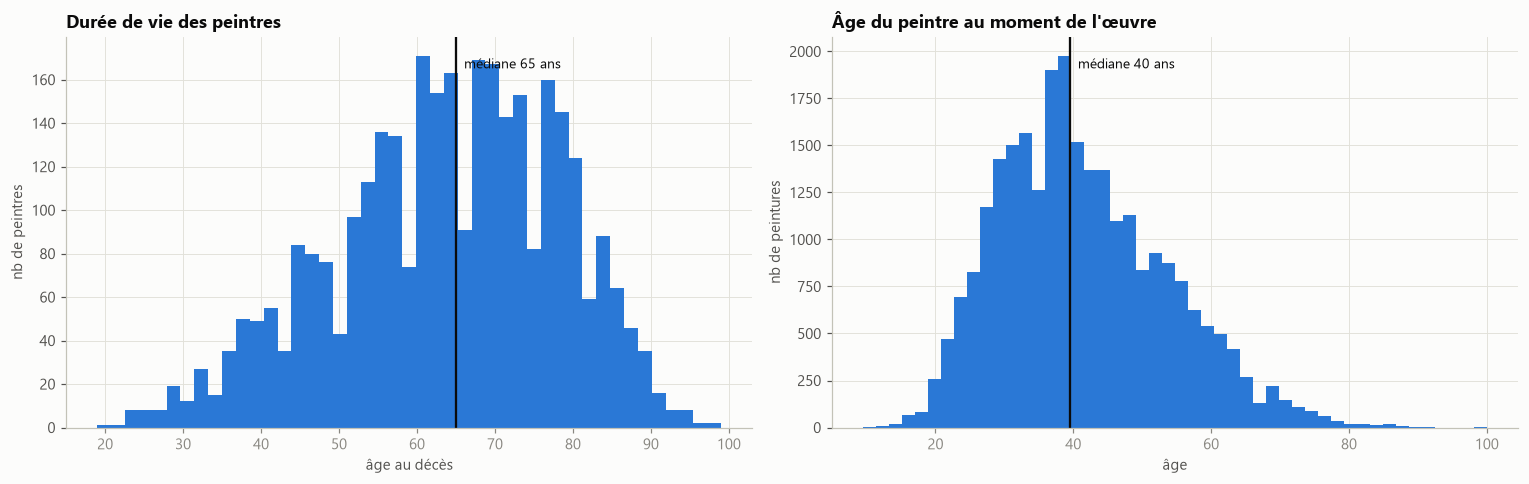

Peintures datées APRÈS la mort du peintre (+1 an de tolérance) : 35 -> erreurs de datation ou achèvement par l'atelier


In [35]:
# Durée de vie et âge de l'artiste au moment de la réalisation
Pa = P.drop_duplicates("AUTHOR")
P["AGE_AT_WORK"] = P["YEAR"] - P["BIRTH_YEAR"]
valid_age = P["AGE_AT_WORK"].between(5, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(Pa["LIFESPAN"].dropna().clip(10, 100), bins=45, color=MAIN)
axes[0].axvline(Pa["LIFESPAN"].median(), color=INK, lw=1.5)
axes[0].text(Pa["LIFESPAN"].median(), axes[0].get_ylim()[1] * 0.92, f"  médiane {Pa['LIFESPAN'].median():.0f} ans", fontsize=9)
axes[0].set_title("Durée de vie des peintres"); axes[0].set_xlabel("âge au décès"); axes[0].set_ylabel("nb de peintres")

axes[1].hist(P.loc[valid_age, "AGE_AT_WORK"], bins=48, color=MAIN)
axes[1].axvline(P.loc[valid_age, "AGE_AT_WORK"].median(), color=INK, lw=1.5)
axes[1].text(P.loc[valid_age, "AGE_AT_WORK"].median(), axes[1].get_ylim()[1] * 0.92,
             f"  médiane {P.loc[valid_age, 'AGE_AT_WORK'].median():.0f} ans", fontsize=9)
axes[1].set_title("Âge du peintre au moment de l'œuvre"); axes[1].set_xlabel("âge"); axes[1].set_ylabel("nb de peintures")
plt.tight_layout()
save(fig, "14_lifespan_age")
plt.show()

posthume = (P["YEAR_START"] > P["DEATH_YEAR"] + 1).sum()
print(f"Peintures datées APRÈS la mort du peintre (+1 an de tolérance) : {posthume} "
      f"-> erreurs de datation ou achèvement par l'atelier")

**Observations**

- La répartition des peintures entre artistes est **très inégalitaire** (Gini = 0,70) : 1 % des peintres fournissent
  24 % des peintures, 10 % en fournissent 61 %, et un quart des peintres n'a qu'une seule œuvre. En tête, Giotto
  (567 lignes, dont 52 % de détails de fresques), Van Gogh, Rembrandt, Rubens et Raphaël.
- Les quelques dizaines de maîtres les plus représentés imprimeront leur style au GAN bien plus que les milliers
  d'autres : les générations ressembleront davantage à du Giotto ou du Van Gogh qu'à la « moyenne » de la peinture.
- Les peintres vivent en médiane 65 ans et peignent les œuvres du catalogue vers 40 ans. Quelques dizaines d'œuvres
  sont datées après la mort de leur auteur : achèvement par l'atelier ou erreur de datation.

### 5.7 Titres : sujets représentés et quasi-doublons

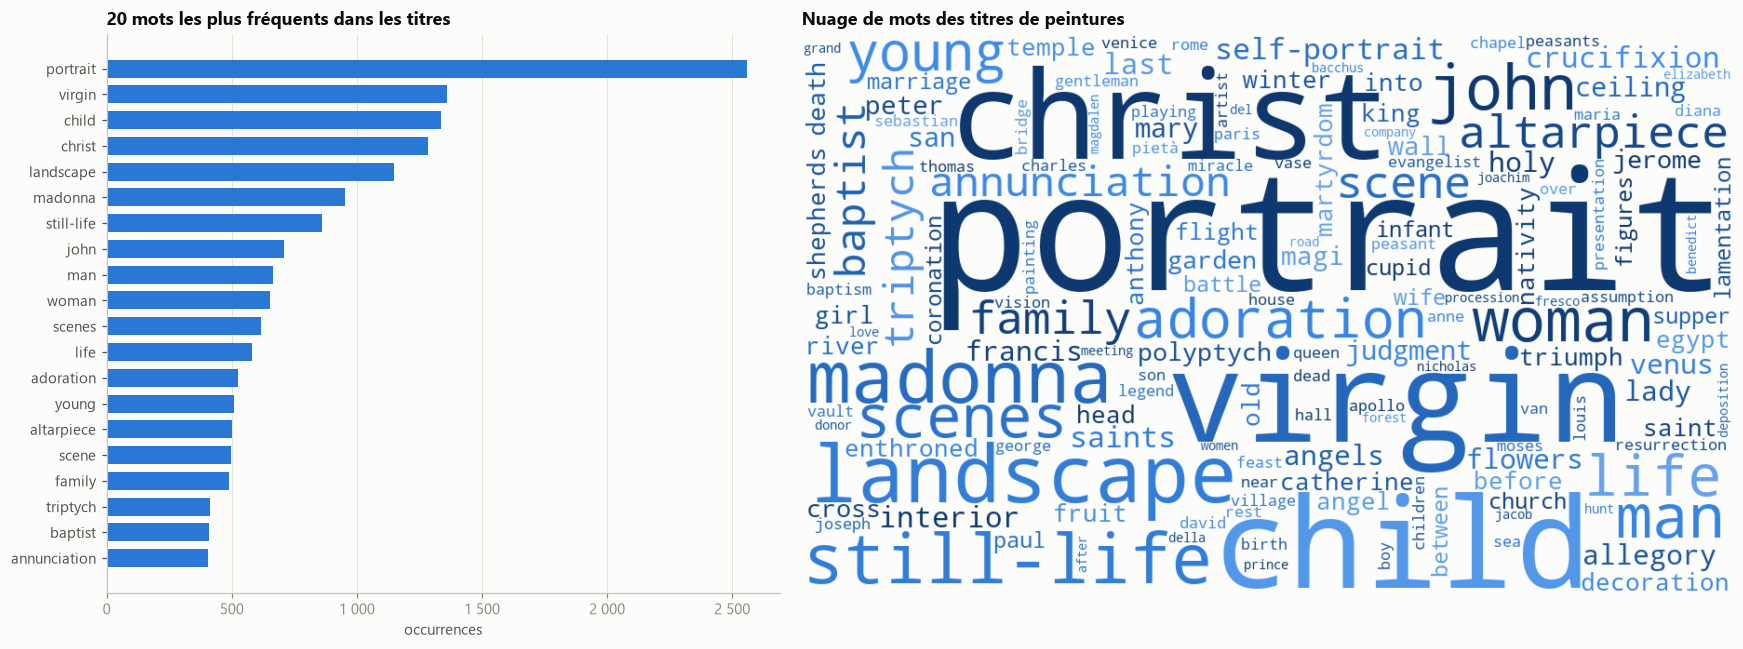

In [36]:
STOP = set(("the a an of and in on at to with from by for his her their its is as detail details "
            "part two three four five one six left right wing panel central st sts view").split())
words = (P["TITLE"].str.lower().str.replace(r"[^a-zà-ÿ\s-]", " ", regex=True).str.split().explode())
words = words[(words.str.len() > 2) & ~words.isin(STOP)]
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})
barh(words.value_counts().head(20), "20 mots les plus fréquents dans les titres", xlabel="occurrences", ax=axes[0], label=False)
SEQ_DARK = LinearSegmentedColormap.from_list("seq_dark", SEQ(np.linspace(0.45, 1, 64)))   # mots lisibles
wc = WordCloud(width=1000, height=600, background_color=SURFACE, colormap=SEQ_DARK, max_words=150,
               random_state=0).generate_from_frequencies(words.value_counts().to_dict())
axes[1].imshow(wc, interpolation="bilinear"); axes[1].axis("off")
axes[1].set_title("Nuage de mots des titres de peintures")
plt.tight_layout()
save(fig, "15_title_words")
plt.show()

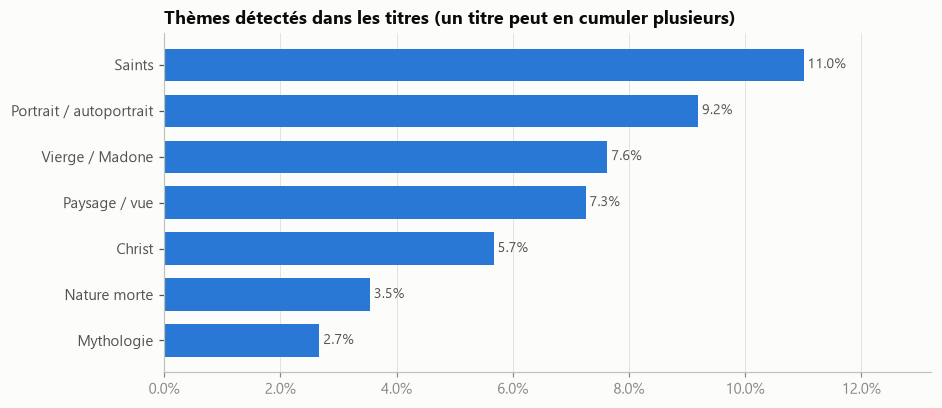

In [37]:
THEMES = {
    "Vierge / Madone": r"\b(virgin|madonna|mary)\b",
    "Christ": r"\b(christ|jesus|crucifixion|pietà|lamentation|resurrection)\b",
    "Saints": r"\b(st|saint|sts)\b",
    "Portrait / autoportrait": r"portrait",
    "Paysage / vue": r"\b(landscape|view|river|sea|seascape|harbour)\b",
    "Nature morte": r"still-?life|flowers|fruit",
    "Mythologie": r"\b(venus|apollo|bacchus|jupiter|diana|mars|mercury|nymph|cupid|hercules)\b",
}
th = pd.Series({k: P["TITLE"].str.contains(v, case=False, regex=True).mean() for k, v in THEMES.items()}).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(th.index, th.values, color=MAIN, height=0.7)
for i, v in enumerate(th.values):
    ax.text(v, i, f" {v:.1%}", va="center", fontsize=9, color=INK2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.grid(axis="y", visible=False)
ax.set_xlim(0, th.max() * 1.2)
ax.set_title("Thèmes détectés dans les titres (un titre peut en cumuler plusieurs)")
save(fig, "16_title_themes")
plt.show()

In [38]:
# Quasi-doublons : détails + vues multiples d'une même œuvre
P["N_SAME_WORK"] = P.groupby(["AUTHOR", "TITLE_BASE"])["URL"].transform("count")
near_dup = P["IS_DETAIL"] | P.drop(columns=["URL", "IMAGE_URL"]).duplicated(keep="first")
print(f"Titres « detail » : {P['IS_DETAIL'].sum():,} ({P['IS_DETAIL'].mean():.1%})".replace(",", " "))
print(f"Quasi-doublons (détails + lignes identiques hors URL) : {near_dup.sum():,} ({near_dup.mean():.1%})".replace(",", " "))
print(f"Peintures après retrait des quasi-doublons : {(~near_dup).sum():,}".replace(",", " "))

det = P.groupby("MEDIUM_FAMILY")["IS_DETAIL"].mean().sort_values(ascending=False)
print("\nPart de « détails » selon la technique :")
print(det.map("{:.1%}".format).to_string())

print("\nŒuvres les plus découpées en détails :")
P.groupby(["AUTHOR", "TITLE_BASE"]).size().sort_values(ascending=False).head(8).to_frame("nb lignes")

Titres « detail » : 5 056 (15.6%)
Quasi-doublons (détails + lignes identiques hors URL) : 5 802 (17.9%)
Peintures après retrait des quasi-doublons : 26 636

Part de « détails » selon la technique :
MEDIUM_FAMILY
Fresque                       35.5%
Huile + tempera               25.9%
Tempera                       24.1%
Non précisé (support seul)    13.8%
Huile                         10.6%
Autre                          8.9%
Techniques sur papier          1.3%

Œuvres les plus découpées en détails :


nb lignes
AUTHOR                    TITLE_BASE                                       
GIOTTO di Bondone         Last Judgment                                  37
MICHELANGELO Buonarroti   Last Judgment                                  32
BOSCH, Hieronymus         Triptych of Garden of Earthly Delights         27
BRUEGEL, Pieter the Elder The Tower of Babel                             24
                          Children's Games                               23
MICHELANGELO Buonarroti   Ignudo                                         23
CAVALLINI, Pietro         Last Judgment                                  22
WEYDEN, Rogier van der    The Last Judgment                              22

**Observations**

- Les titres confirment le biais religieux : *Virgin*, *Child*, *Christ*, *Madonna* figurent parmi les mots les plus
  fréquents, même si *portrait* arrive en tête (terme générique d'un genre à part entière).
- **16 % des peintures sont des détails** et près de 18 % sont des quasi-doublons au total. Les fresques sont les plus
  concernées (**35 % de détails**) : le *Jugement dernier* de Giotto est découpé en 37 lignes, celui de Michel-Ange en 32.
  Pour le GAN, ces recadrages d'une même œuvre sont autant de copies proches qui poussent à la mémorisation.
- Retirer les quasi-doublons laisse **26 636 peintures**, largement suffisant pour l'entraînement.

### 5.8 Lieux de conservation

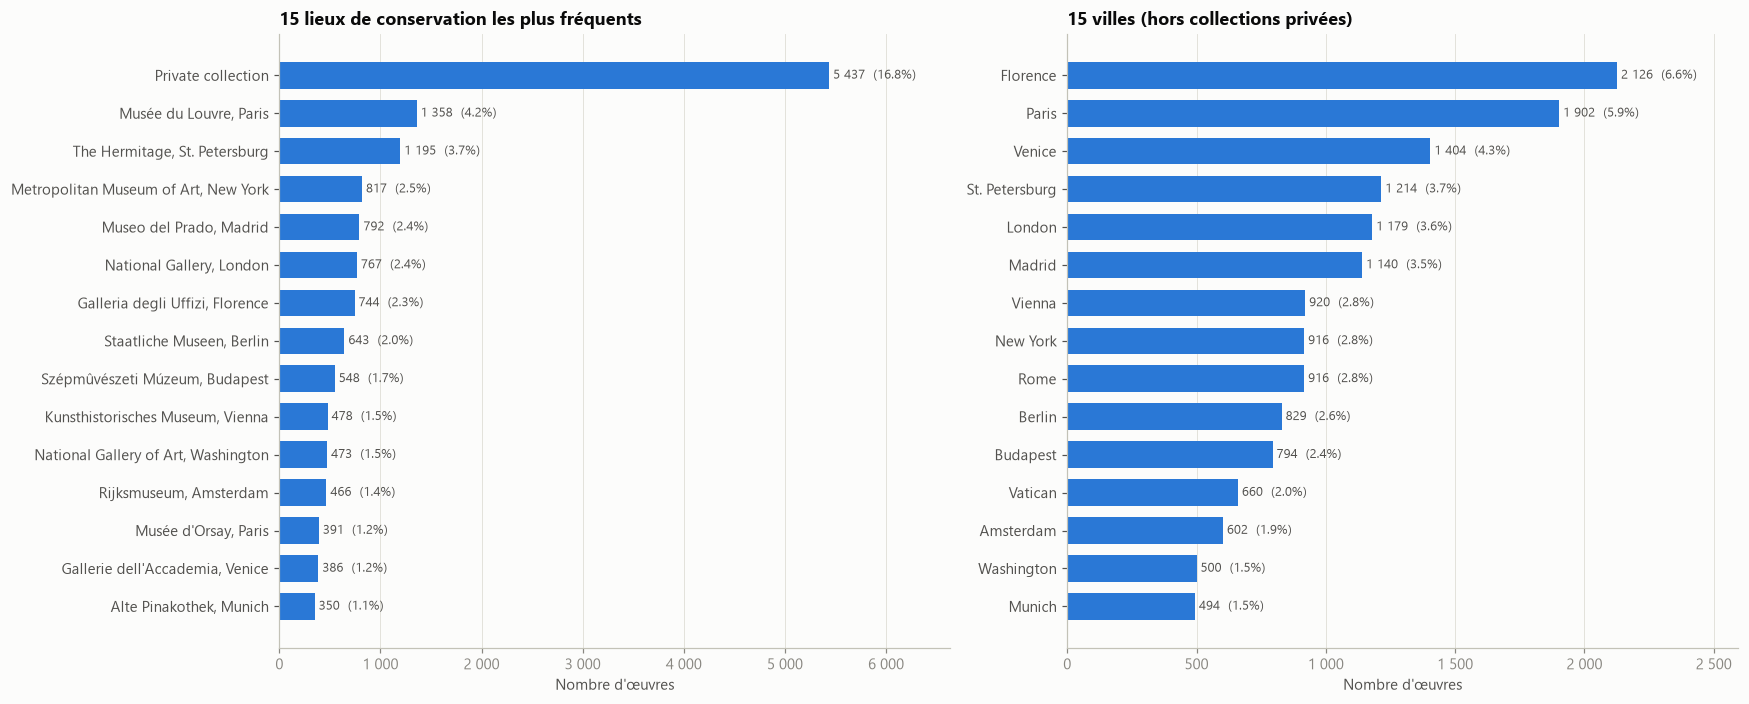

Collections privées : 16.8% des peintures
Lieux distincts : 2 284 ; villes : 876
Fresques conservées in situ (églises, chapelles, palais…) : 65.4%


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
barh(P["LOCATION"].value_counts().head(15), "15 lieux de conservation les plus fréquents", ax=axes[0], pct_of=n)
barh(P["CITY"].value_counts().head(15), "15 villes (hors collections privées)", ax=axes[1], pct_of=n)
plt.tight_layout()
save(fig, "17_locations")
plt.show()

print(f"Collections privées : {P['IS_PRIVATE'].mean():.1%} des peintures")
print(f"Lieux distincts : {P['LOCATION'].nunique():,} ; villes : {P['CITY'].nunique():,}".replace(",", " "))
fresco_loc = P.loc[P["MEDIUM_FAMILY"] == "Fresque", "LOCATION"].str.contains(
    r"chapel|church|cappella|chiesa|basilica|palazzo|villa|cathedral|duomo|oratorio|monastery|convent", case=False).mean()
print(f"Fresques conservées in situ (églises, chapelles, palais…) : {fresco_loc:.1%}")

**Observations** — les **collections privées** sont le premier « lieu » (17 % des peintures), devant le Louvre,
l'Ermitage, le Metropolitan Museum et le Prado. Les images des œuvres en collection privée risquent d'être de
qualité plus hétérogène (sources variées) — à vérifier après scraping. Au moins 65 % des fresques sont conservées
**in situ** (églises, chapelles, palais) : leurs photos incluront murs, voûtes, moulures et perspective.

## 6. Analyse multivariée et tests statistiques

### 6.1 Associations entre variables catégorielles — V de Cramér

Le **V de Cramér** (version corrigée du biais, Bergsma 2013) mesure l'intensité de l'association entre deux variables
catégorielles, de 0 (indépendance) à 1 (association parfaite). Il permet de repérer les variables redondantes
et celles qui structurent le corpus.

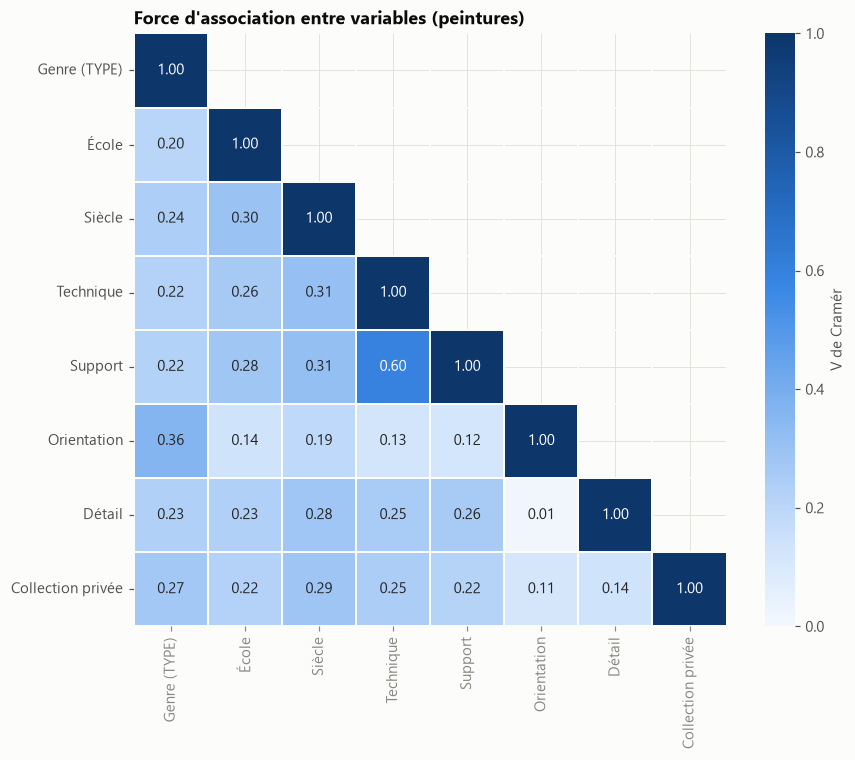

In [40]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    nn = ct.values.sum()
    r, k = ct.shape
    phi2 = max(0, chi2 / nn - (k - 1) * (r - 1) / (nn - 1))
    rc, kc = r - (r - 1) ** 2 / (nn - 1), k - (k - 1) ** 2 / (nn - 1)
    return np.sqrt(phi2 / max(1e-12, min(kc - 1, rc - 1)))


P["SCHOOL_TOP"] = top_n(P["SCHOOL"], 10)
VARS = {"Genre (TYPE)": "TYPE", "École": "SCHOOL_TOP", "Siècle": "CENTURY_LBL", "Technique": "MEDIUM_FAMILY",
        "Support": "SUPPORT", "Orientation": "ORIENTATION", "Détail": "IS_DETAIL", "Collection privée": "IS_PRIVATE"}
names = list(VARS)
M = pd.DataFrame(np.eye(len(names)), index=names, columns=names)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        sub = P[[VARS[a], VARS[b]]].dropna()
        M.loc[a, b] = M.loc[b, a] = cramers_v(sub[VARS[a]].astype(str), sub[VARS[b]].astype(str))

mask = np.triu(np.ones_like(M, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(M, mask=mask, cmap=SEQ, vmin=0, vmax=1, annot=True, fmt=".2f", linewidths=1, linecolor=SURFACE,
            cbar_kws={"label": "V de Cramér"}, ax=ax, square=True)
ax.set_title("Force d'association entre variables (peintures)")
save(fig, "18_cramers_v")
plt.show()

**Observations** — l'association la plus forte relie **technique et support** (V = 0,60), ce qui est attendu
(la fresque implique le mur, la tempera le bois). Viennent ensuite **genre et orientation** (0,36 : portraits verticaux,
paysages horizontaux), puis le **siècle** avec la technique, le support et l'école (≈ 0,30). Aucune paire n'est
redondante au point de justifier la suppression d'une variable, mais toutes sont liées : filtrer sur l'une déplace
la distribution des autres.

### 6.2 Test du χ² d'indépendance École × Genre et résidus standardisés

Le test indique *si* les deux variables sont liées ; les **résidus standardisés ajustés** indiquent *où* :
une case > +2 est significativement sur-représentée, < −2 sous-représentée.

χ² = 11 450  ddl = 63  p-value = 0.0e+00


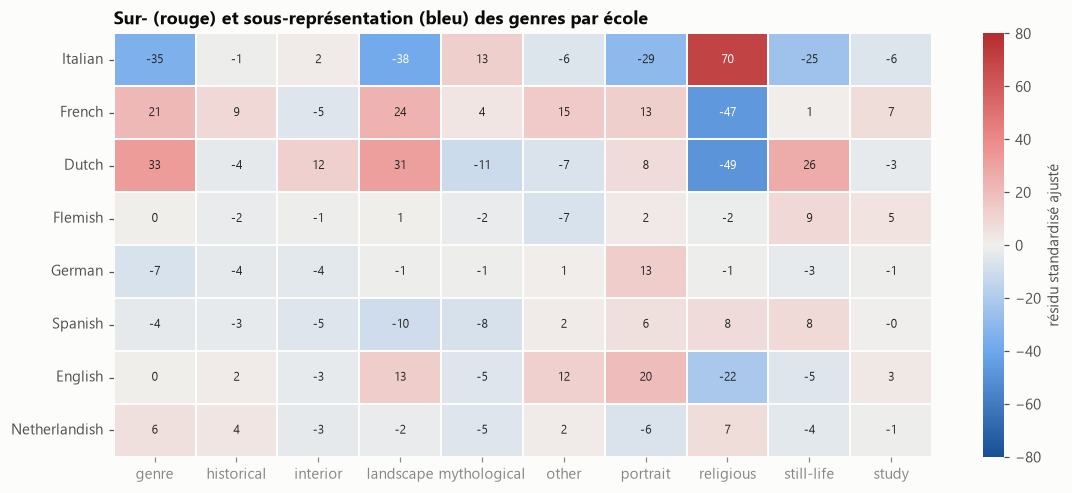

In [41]:
top8 = P["SCHOOL"].value_counts().index[:8]
sub = P[P["SCHOOL"].isin(top8)]
ct = pd.crosstab(sub["SCHOOL"], sub["TYPE"]).loc[top8]
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"χ² = {chi2:,.0f}, ddl = {dof}, p-value = {p:.1e}".replace(",", " "))

N = ct.values.sum()
rs = ct.sum(axis=1).values[:, None] / N
cs = ct.sum(axis=0).values[None, :] / N
adj = (ct - exp) / np.sqrt(exp * (1 - rs) * (1 - cs))
lim = np.ceil(np.abs(adj.values).max() / 10) * 10

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(adj, cmap=DIV, center=0, vmin=-lim, vmax=lim, annot=True, fmt=".0f", annot_kws={"size": 8},
            linewidths=1, linecolor=SURFACE, cbar_kws={"label": "résidu standardisé ajusté"}, ax=ax)
ax.set_title("Sur- (rouge) et sous-représentation (bleu) des genres par école")
ax.set_xlabel(""); ax.set_ylabel("")
save(fig, "19_chi2_residuals")
plt.show()

**Observations** — l'indépendance est très nettement rejetée (p ≈ 0). La case la plus extrême est
**Italie × religieux** (résidu ≈ +70), à l'opposé de la Hollande et de la France, où le religieux est fortement
sous-représenté (≈ −50) au profit du paysage, de la scène de genre et de la nature morte. L'Angleterre ressort sur
le portrait. Les écoles flamande et allemande ont le profil le plus proche de la moyenne.

## 7. Synthèse et implications pour le GAN

In [42]:
summary = pd.Series({
    "Peintures au catalogue": len(P),
    "… dont titres « detail »": int(P["IS_DETAIL"].sum()),
    "… dont quasi-doublons au total": int(near_dup.sum()),
    "… dont fresques": int((P["MEDIUM_FAMILY"] == "Fresque").sum()),
    "Peintures uniques hors fresques": int((~near_dup & (P["MEDIUM_FAMILY"] != "Fresque")).sum()),
    "Part religieuse": f"{(P['TYPE'] == 'religious').mean():.1%}",
    "Part italienne": f"{(P['SCHOOL'] == 'Italian').mean():.1%}",
    "Part XVe-XVIIe siècles": f"{P['CENTURY'].between(15, 17).mean():.1%}",
    "Perte médiane au recadrage carré": f"{Pd['CROP_LOSS'].median():.1%}",
}, name="valeur").to_frame()
summary

,valeur
Peintures au catalogue,32438
… dont titres « detail »,5056
… dont quasi-doublons au total,5802
… dont fresques,4683
Peintures uniques hors fresques,23991
Part religieuse,41.7%
Part italienne,42.4%
Part XVe-XVIIe siècles,65.4%
Perte médiane au recadrage carré,24.4%


### Ce que dit le catalogue

**1. Un volume confortable pour un GAN.** Le catalogue contient ~32 400 peintures, soit l'ordre de grandeur de
CIFAR-10 (50 000) ou de FFHQ (70 000). Même après nettoyage des quasi-doublons, on reste bien au-dessus
du seuil de quelques milliers d'images au-delà duquel un DCGAN produit des résultats exploitables (cf. veille, Q8).

**2. Un corpus très biaisé — le GAN apprendra « la peinture européenne religieuse de la Renaissance ».**
- Genre : 42 % des peintures sont **religieuses** ; les thèmes Vierge, Christ et saints saturent les titres.
- Géographie : l'**école italienne** représente à elle seule 42 % des peintures, et les 5 premières écoles
  (italienne, française, hollandaise, flamande, allemande) 87 %.
- Époque : 65 % des peintures datent des **XVᵉ-XVIIᵉ siècles** ; rien après 1900.
- Artistes : distribution à très longue traîne (Gini = 0,70) ; 1 % des peintres fournissent un quart des peintures.

Sans intervention, les générations seront majoritairement des **madones et des scènes religieuses aux tons ocre
et dorés**. C'est un choix artistique acceptable, mais il faut le **savoir et l'assumer** — ou le corriger.

**3. Les variables sont fortement liées entre elles.** Le V de Cramér montre que le siècle, l'école et la technique
sont très associés : la fresque et la tempera marquent l'Italie médiévale et le Quattrocento, l'huile sur toile
domine à partir du XVIIᵉ siècle. Choisir un sous-ensemble sur une variable revient à en filtrer implicitement d'autres.

**4. Les quasi-doublons sont nombreux.** Les titres « (detail) » et les lignes identiques hors URL représentent
18 % des peintures — 35 % parmi les **fresques**, massivement découpées en détails. Garder ces lignes revient à montrer
plusieurs fois la même œuvre au GAN : risque de **mémorisation** et de sur-pondération.

**5. Les fresques sont un cas à part.** Photographiées **in situ** (murs, voûtes, architecture autour), elles
introduisent perspective, éclairage et cadre architectural qui ne sont pas « la peinture ».

**6. Les formats sont hétérogènes et bimodaux.** 55 % des tableaux sont verticaux, 41 % horizontaux, à peine 4 %
carrés ; le format dépend fortement du genre. Un recadrage carré centré coupe en médiane 24 % de la surface.

### Recommandations pour la suite

| Étape | Recommandation |
|---|---|
| **Sélection** | `FORM == "painting"` ; retirer les titres « detail » et les doublons hors URL. Envisager d'exclure les fresques (photos in situ). |
| **Scraping** | Utiliser l'`URL` comme clé ; tester la règle `/html/…html → /art/…jpg` sur un échantillon, sinon parser la page HTML. Prévoir un délai entre requêtes (serveur d'un musée associatif). |
| **Preprocessing** | Contrôler le ratio réel des images téléchargées (le cadre photographié diffère des dimensions de la toile). Comparer recadrage centré (perte d'information) et *padding* / redimensionnement avec déformation. Normaliser en `[-1, 1]` pour une sortie `tanh`. |
| **Biais** | Soit assumer le biais « Renaissance religieuse », soit construire un sous-corpus plus homogène (ex. paysages, portraits) — plus facile à apprendre pour un petit GAN —, soit rééquilibrer par échantillonnage. |
| **Augmentation** | Flip horizontal (pertinent pour la plupart des tableaux), pas de rotation. Le dataset d'art abstrait optionnel changera fortement la distribution : à traiter comme une expérience séparée. |
| **Évaluation** | Le FID devra être calculé contre le sous-corpus effectivement utilisé, pas contre le catalogue complet. |

## 8. Export du catalogue des peintures enrichi

On sauvegarde **toutes** les peintures avec les variables construites et les indicateurs de filtrage (`IS_DETAIL`,
`IS_NEAR_DUP`), sans rien supprimer : le choix final du sous-corpus sera fait dans le notebook de modélisation.

In [43]:
P["IS_NEAR_DUP"] = near_dup
EXPORT_COLS = ["AUTHOR", "TITLE", "TITLE_BASE", "DATE", "YEAR_START", "YEAR_END", "YEAR", "DATE_PRECISION",
               "TIMEFRAME", "CENTURY", "SCHOOL", "TYPE", "TECHNIQUE", "MEDIUM", "MEDIUM_FAMILY", "SUPPORT",
               "HEIGHT_CM", "WIDTH_CM", "ASPECT", "ORIENTATION", "IS_TONDO", "BORN-DIED", "BIRTH_YEAR",
               "DEATH_YEAR", "BIRTH_PLACE", "DEATH_PLACE", "LOCATION", "CITY", "IS_PRIVATE",
               "IS_DETAIL", "IS_NEAR_DUP", "URL", "IMAGE_URL"]
out_path = DATA_OUT / "paintings_catalog.csv"
P[EXPORT_COLS].to_csv(out_path, index=False, encoding="utf-8")
print(f"{len(P):,} peintures exportées -> {out_path.relative_to(ROOT)}".replace(",", " "))
print(f"Figures sauvegardées dans {FIG_DIR.relative_to(ROOT)} : {len(list(FIG_DIR.glob('*.png')))} fichiers")

32 438 peintures exportées -> data\processed\paintings_catalog.csv
Figures sauvegardées dans reports\figures : 19 fichiers
